In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
from ast import literal_eval
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import os

In [2]:
# Define helper functions
def load_csv(filename):
    return pd.read_csv(filename, sep=',')

def calculate_group_average(df):
    return df.groupby(['Label', 'Conc']).mean()

def transform_label(label):
    # Check for condition 1: Replace specific strings with 'Reference'
    if label in (["['AF']", "['AgNR@SiO2']", "['DMEM']"]):
        return "['Reference']"
    
    # Check for condition 2: Replace 'COVNL63' or 'CoVNL63' with 'CoVNL63'
    if 'COVNL63' in label or 'CoVNL63' in label:
        label = label.replace('COVNL63', 'CoVNL63')
        label = label.replace('CoVNL63', 'CoVNL63')
        label = label.replace('CovNL63', 'CoVNL63')
    
    return label

def inspect_dataframe(df):
    """
    Inspects a DataFrame to understand its structure, particularly the Label and Conc columns.
    """
    print("DataFrame shape:", df.shape)
    print("\nColumn names:", df.columns.tolist())
    
    # Inspect index structure
    print("\nIndex type:", type(df.index))
    print("First 5 index values:", df.index[:5])
    
    if 'Label' in df.columns or ('Label' in df.index.names):
        # Get unique labels
        if 'Label' in df.columns:
            labels = df['Label'].unique()
        else:
            # For MultiIndex
            labels = df.index.get_level_values('Label').unique()
        
        print("\nUnique Label values (first 10):")
        for i, label in enumerate(labels[:10]):
            print(f"{i+1}. {repr(label)} (Type: {type(label)})")
    
    if 'Conc' in df.columns or ('Conc' in df.index.names):
        # Get unique concentrations
        if 'Conc' in df.columns:
            concs = df['Conc'].unique()
        else:
            # For MultiIndex
            concs = df.index.get_level_values('Conc').unique()
        
        print("\nUnique Conc values (first 10):")
        for i, conc in enumerate(concs[:10]):
            print(f"{i+1}. {repr(conc)} (Type: {type(conc)})")
    
    # Check for problematic mixed virus entries
    if isinstance(df.index, pd.MultiIndex) and 'Label' in df.index.names:
        print("\nChecking for mixed virus entries:")
        for idx in df.index:
            label = idx[df.index.names.index('Label')]
            if "__" in str(label):
                print(f"Found mixed virus: {repr(label)}")
                # Print the full row for this index
                print(f"  Row data: {idx}")
                break

def parse_mixed_virus_data(fixed_df):
    """
    Parse virus names and concentrations from mixed virus data.
    Uses ast.literal_eval to safely parse the Label strings as Python literals,
    ensuring accurate virus type detection.
    """
    import ast  # For safely evaluating the label as a Python literal
    
    # Create dictionary to store parsed results
    parsed_data = {}
    
    # Reset index to access the Label and Conc columns
    fixed_df_reset = fixed_df.reset_index()
    
    # Process each row
    for idx, row in fixed_df_reset.iterrows():
        label = row['Label']
        conc = row['Conc']
        
        # Parse the virus names from the label using literal_eval
        virus_names = []
        if isinstance(label, str):
            try:
                # Parse the label as a Python literal (usually a list of strings)
                parsed_label = ast.literal_eval(label)
                
                if isinstance(parsed_label, list):
                    # Successfully parsed as a list
                    virus_names = parsed_label
                else:
                    # Not a list, just use the single item
                    virus_names = [str(parsed_label)]
            except (SyntaxError, ValueError):
                # If parsing fails, fall back to simple string handling
                clean_label = label.strip("[]' ")
                virus_names = [clean_label]
        
        # Parse the concentrations from the conc - for clean CSV format with brackets
        concentrations = []
        if isinstance(conc, str):
            try:
                # Try to parse the concentration as a Python literal first
                parsed_conc = ast.literal_eval(conc)
                
                if isinstance(parsed_conc, list):
                    # It's a list of concentrations
                    concentrations = [float(c) for c in parsed_conc]
                else:
                    # Single concentration
                    concentrations = [float(parsed_conc)]
            except (SyntaxError, ValueError):
                # If parsing fails, fall back to string splitting
                # First, remove any surrounding brackets if present
                clean_conc = conc.strip()
                if clean_conc.startswith('[') and clean_conc.endswith(']'):
                    clean_conc = clean_conc[1:-1]  # Remove the brackets
                
                # Handle the format with comma separators
                if "," in clean_conc:
                    # Split by comma and convert each part to float
                    parts = clean_conc.split(",")
                    for part in parts:
                        part = part.strip()
                        if part:  # Skip empty strings
                            try:
                                concentrations.append(float(part))
                            except ValueError:
                                print(f"Warning: Could not convert '{part}' to float")
                else:
                    # No separators, just a single value
                    if clean_conc:
                        try:
                            concentrations.append(float(clean_conc))
                        except ValueError:
                            print(f"Warning: Could not convert '{clean_conc}' to float")
        elif isinstance(conc, (int, float)):
            concentrations.append(conc)
        
        # Determine the type of mixture
        if len(virus_names) == 1:
            parsed_type = "single"
        elif len(virus_names) == 2:
            parsed_type = "double"
        elif len(virus_names) == 3:
            parsed_type = "triple"
        else:
            parsed_type = f"multiple({len(virus_names)})"
        
        # Store the parsed data using the original index as key
        original_idx = (label, conc)
        parsed_data[original_idx] = {
            "type": parsed_type,
            "virus_names": virus_names,
            "concentrations": concentrations
        }
    
    return parsed_data

def get_single_virus_highest_concentration_rows(avg_df):
    """
    Get the highest concentration row for each single virus (excluding mixed virus samples).
    Updated to handle the clean CSV format with bracketed values.
    
    Args:
        avg_df: DataFrame with virus data, may include mixed virus samples
        
    Returns:
        DataFrame with highest concentration row for each single virus
    """
    avg_df_reset = avg_df.reset_index()
    
    print("Extracting single virus data...")
    
    # Filter for single virus labels only
    single_virus_mask = avg_df_reset['Label'].apply(
        lambda x: isinstance(x, str) and 
                 not '__' in x and  # Skip mixed virus labels with '__'
                 len(x.strip("[]").replace("'", "").split(", ")) == 1
    )
    
    single_virus_df = avg_df_reset[single_virus_mask].copy()
    print(f"Found {len(single_virus_df)} single virus samples")
    
    if single_virus_df.empty:
        print("No single virus samples found!")
        return pd.DataFrame()
    
    # Print some example concentration values for debugging
    print("Example concentration values:")
    print(single_virus_df['Conc'].head(5).to_list())
    
    # Parse concentration values for single virus samples - Updated for clean CSV format with brackets
    def parse_conc(x):
        try:
            if isinstance(x, str):
                # First, remove any surrounding brackets if present
                clean_str = x.strip()
                if clean_str.startswith('[') and clean_str.endswith(']'):
                    clean_str = clean_str[1:-1]  # Remove the first and last characters (brackets)
                
                # Handle new format with comma separators
                if "," in clean_str:
                    # For single virus, just take the first value before comma
                    first_value = clean_str.split(",")[0].strip()
                    return float(first_value)
                else:
                    # Just try to convert to float directly
                    return float(clean_str)
            elif isinstance(x, list):
                # If it's already a list, return the first element
                return float(x[0])
            else:
                # If it's a scalar value, return it as is
                return float(x)
        except Exception as e:
            print(f"Error parsing concentration: {x}, Error: {e}")
            # Return the original value if parsing fails
            return x
    
    # Apply the parsing function
    single_virus_df['Conc_parsed'] = single_virus_df['Conc'].apply(parse_conc)
    
    # For debugging
    print("After parsing concentrations:")
    print(single_virus_df[['Label', 'Conc', 'Conc_parsed']].head())
    
    # Get unique single virus labels
    unique_virus_labels = single_virus_df['Label'].unique()
    print(f"Found {len(unique_virus_labels)} unique single virus types")
    
    # Get highest concentration for each virus
    highest_conc_rows = []
    for label in unique_virus_labels:
        label_rows = single_virus_df[single_virus_df['Label'] == label]
        if not label_rows.empty:
            try:
                # Sort by parsed concentration and get highest
                highest_conc_row = label_rows.sort_values(by='Conc_parsed', ascending=False).iloc[0]
                # Remove the temporary Conc_parsed column before adding to results
                highest_conc_row = highest_conc_row.drop('Conc_parsed')
                highest_conc_rows.append(highest_conc_row)
                print(f"Highest concentration for {label}: {highest_conc_row['Conc']}")
            except Exception as e:
                print(f"Error processing {label}: {str(e)}")
    
    result_df = pd.DataFrame(highest_conc_rows)
    print(f"Final result has {len(result_df)} rows")
    return result_df
    
def fit_least_squares(components, target, lam=1.0, regularization="None"):
    X = np.column_stack(components)
    y = target.values.reshape(-1, 1).ravel()
    num_vars = X.shape[1]
    
    # Objective function: Sum of squared residuals with regularization
    def objective(coefs):
        predictions = X @ coefs
        residuals = y - predictions
        reg_term = 0
        if regularization == "ridge":
            reg_term = lam * np.sum(coefs**2)
        elif regularization == "lasso":
            reg_term = lam * np.sum(np.abs(coefs))
        elif regularization == "None":
            reg_term = 0
        return np.sum(residuals**2) + reg_term
    
    # Constraints: Coefficients sum to 1
    cons = {'type': 'eq', 'fun': lambda coefs: np.sum(coefs) - 1}
    
    # Bounds: Coefficients are non-negative
    bounds = [(1e-10, 1) for _ in range(num_vars)]
    
    # Initial guess: all ones
    initial_coefs = np.ones(num_vars)
    
    # Perform optimization
    result = minimize(objective, initial_coefs, bounds=bounds, constraints=cons)
    
    if not result.success:
        raise ValueError("Constrained optimization failed!")
    
    coefficients = result.x
    
    return coefficients, 0

def process_dataframe(fixed_df, parsed_data, highest_single_virus_conc_df, saliva_series, reference_series):
    """
    Process the dataframe and return predicted spectra and fit results.
    """
    # Initialize DataFrame to store results
    predicted_df = pd.DataFrame()
    result_df = pd.DataFrame(columns=['Label', 'Conc', 'Coefficients', 'Intercept', 'MAE', 'RMSE', 'R2'])
    
    # Process each sample
    for (label, conc), target_avg in fixed_df.iterrows():
        if 'Reference' not in str(label):  # Skip reference samples
            print(f"\nProcessing sample: Label={label}, Conc={conc}")
            
            try:
                # Get the parsed virus names and concentrations
                parsed_idx = (label, conc)
                if parsed_idx in parsed_data:
                    virus_data = parsed_data[parsed_idx]
                    virus_names = virus_data["virus_names"]
                    concentrations = virus_data["concentrations"]
                else:
                    print(f"Warning: No parsed data found for {parsed_idx}")
                    continue
                    
                print(f"Parsed viruses: {virus_names}")
                print(f"Parsed concentrations: {concentrations}")
                
                # Get the average values for each of the single-virus components
                components = []
                for virus_name in virus_names:
                    # Format the virus name for lookup
                    formatted_virus = f"['{virus_name}']"
                    matching_rows = highest_single_virus_conc_df[highest_single_virus_conc_df['Label'] == formatted_virus]
                    
                    if matching_rows.empty:
                        print(f"Warning: No data found for virus '{virus_name}'")
                        continue
                    
                    # Get the highest concentration data for this virus
                    virus_component = matching_rows.iloc[0, 2:].astype(float)
                    components.append(virus_component)
                
                # Add reference component
                components.append(saliva_series)
                components.append(reference_series)
                
                if len(components) < 2:
                    print(f"Warning: Not enough components found for label {label}")
                    continue
                
                # Perform least squares fitting
                coefficients, intercept = fit_least_squares(components, target_avg)
                print(f"Fitted coefficients: {coefficients}")
                
                # Compute predicted values
                predicted_avg = sum(comp * coef for comp, coef in zip(components, coefficients)) + intercept
                
                # Compute MAE, RMSE, and R2
                mae = mean_absolute_error(target_avg, predicted_avg)
                rmse = np.sqrt(mean_squared_error(target_avg, predicted_avg))
                r2 = r2_score(target_avg, predicted_avg)
                
                # Compute VIFs for predictors
                X_with_const = add_constant(np.column_stack(components))
                
                # Handle NaN or infinite values
                for i, comp in enumerate(components):
                    if not np.isfinite(comp).all():
                        print(f"Warning: Component {i} contains NaNs or infinities")
                        components[i] = comp.fillna(0).replace([np.inf, -np.inf], 0)
                
                # Calculate VIF for each predictor
                vifs = [variance_inflation_factor(X_with_const, i) for i in range(X_with_const.shape[1])]
                vifs = vifs[1:]  # Exclude constant term
                
                # Append results to DataFrame
                data_dict = predicted_avg.to_dict()
                data_dict['Label'] = label
                data_dict['Conc'] = conc
                
                # Add to predicted_df
                predicted_df = pd.concat([predicted_df, pd.DataFrame([data_dict])], ignore_index=True)
                
                # Add to result_df
                result_row = {
                    'Label': label, 
                    'Conc': conc, 
                    'Coefficients': coefficients, 
                    'Intercept': intercept, 
                    'MAE': mae, 
                    'RMSE': rmse, 
                    'R2': r2, 
                    'VIFs': vifs
                }
                result_df = pd.concat([result_df, pd.DataFrame([result_row])], ignore_index=True)
                
            except Exception as e:
                print(f"Error processing label={label}, conc={conc}: {str(e)}")
                import traceback
                traceback.print_exc()
                # Continue to the next sample
                continue
    
    return predicted_df, result_df

In [3]:
# Set up the paths and folders
WORKING_PATH = "/home/zhao/Jiaheng Cui/Coefficient_fitting"
DATA_FOLDER = WORKING_PATH + "/data/linear decomposition"
DATE = "05062025"
RESULT_FOLDER = WORKING_PATH + f"/{DATE} - reconstructed vs real only using GLF (saliva, with background)"
os.makedirs(RESULT_FOLDER, exist_ok=True)

In [ ]:
# Step 1: Load CSV data
filename = DATA_FOLDER + "/test2_virus_in_saliva.csv"
df = pd.read_csv(filename, sep=',')

# Apply label transformation
df['Label'] = df['Label'].apply(transform_label)
df

,450,451,452,453,454,455,456,457,458,459,...,1693,1694,1695,1696,1697,1698,1699,1700,Label,Conc
0,-0.012,-0.030,-0.026,-0.011,0.015,0.048,0.121,0.110,0.067,0.001,...,0.394,0.319,0.243,0.158,0.066,-0.038,-0.140,-0.240,['Ad5'],[100.0]
1,-0.064,-0.047,-0.037,-0.027,-0.018,-0.011,-0.003,-0.007,-0.016,-0.029,...,0.516,0.483,0.423,0.327,0.200,0.020,-0.131,-0.254,['Ad5'],[100.0]
2,0.057,0.036,0.024,0.016,0.014,0.015,0.033,0.017,-0.012,-0.050,...,0.464,0.358,0.332,0.259,0.159,-0.008,-0.145,-0.261,['Ad5'],[100.0]
3,-0.043,0.012,0.060,0.110,0.156,0.194,0.243,0.221,0.165,0.082,...,0.443,0.339,0.219,0.111,0.014,-0.058,-0.143,-0.241,['Ad5'],[100.0]
4,0.108,0.082,0.093,0.118,0.156,0.200,0.296,0.274,0.204,0.097,...,0.412,0.318,0.278,0.206,0.115,-0.019,-0.142,-0.256,['Ad5'],[100.0]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119788,0.258,0.273,0.312,0.354,0.396,0.430,0.502,0.447,0.338,0.186,...,0.550,0.468,0.315,0.180,0.052,-0.039,-0.156,-0.292,['saliva'],[20.0]
119789,0.162,0.122,0.131,0.159,0.204,0.260,0.382,0.360,0.283,0.160,...,0.737,0.637,0.411,0.219,0.049,-0.084,-0.172,-0.218,['saliva'],[20.0]
119790,0.148,0.011,-0.011,0.020,0.102,0.223,0.493,0.491,0.389,0.203,...,0.466,0.325,0.291,0.185,0.031,-0.226,-0.442,-0.630,['saliva'],[20.0]
119791,0.119,0.115,0.144,0.187,0.239,0.295,0.405,0.379,0.297,0.171,...,0.530,0.448,0.289,0.153,0.033,-0.061,-0.136,-0.196,['saliva'],[20.0]


In [5]:
# Group and save the grouped data
grouped_df = df.groupby(['Label', 'Conc'], as_index=False).mean()
grouped_df

,Label,Conc,450,451,452,453,454,455,456,457,...,1691,1692,1693,1694,1695,1696,1697,1698,1699,1700
0,['Ad5'],[100.0],0.048205,0.034769,0.040359,0.054718,0.076333,0.101795,0.158513,0.144000,...,0.622128,0.531821,0.448128,0.365333,0.295692,0.205795,0.101718,-0.034179,-0.150641,-0.252846
1,['Ad5'],[100000.0],-0.113179,-0.099769,-0.084282,-0.067487,-0.049667,-0.031231,-0.006641,0.004103,...,0.398205,0.359897,0.323205,0.286154,0.251179,0.211077,0.166103,0.116103,0.061410,0.001462
2,['Ad5'],[12500.0],-0.111897,-0.095821,-0.078692,-0.060641,-0.041949,-0.023641,-0.000128,0.009333,...,0.425744,0.386000,0.346846,0.306333,0.266897,0.221744,0.171513,0.115051,0.055769,-0.007077
3,['Ad5'],[1562.0],-0.075154,-0.072538,-0.062359,-0.048590,-0.031692,-0.012897,0.019026,0.022897,...,0.492051,0.437692,0.386436,0.335179,0.289128,0.234590,0.173308,0.100718,0.029308,-0.042487
4,['Ad5'],[195.0],0.060897,0.054385,0.063615,0.079667,0.100846,0.123615,0.174282,0.155282,...,0.633821,0.532692,0.441179,0.351974,0.278513,0.189205,0.089846,-0.033821,-0.142513,-0.240564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3473,['RSVB1'],[50000.0],0.133487,0.146205,0.158179,0.170077,0.180923,0.189744,0.202256,0.198692,...,0.051821,0.036282,0.011846,-0.017769,-0.059410,-0.095538,-0.128949,-0.154462,-0.185410,-0.221282
3474,['RSVB1'],[6250.0],0.041974,0.060590,0.077846,0.095462,0.111744,0.124846,0.143179,0.135282,...,0.159385,0.112436,0.067333,0.023077,-0.016410,-0.061205,-0.109872,-0.169026,-0.222282,-0.272231
3475,['RSVB1'],[781.0],0.087026,0.075462,0.076846,0.083538,0.094513,0.107410,0.143000,0.125179,...,0.454487,0.367128,0.285000,0.204641,0.135846,0.054333,-0.035615,-0.146974,-0.243795,-0.330359
3476,['saliva'],[10.0],0.163114,0.143486,0.139286,0.141629,0.148714,0.157886,0.194343,0.164457,...,0.593543,0.485571,0.381714,0.278286,0.183143,0.079657,-0.028743,-0.150286,-0.265000,-0.376486


In [6]:
pd.DataFrame(grouped_df).to_csv(DATA_FOLDER + f"/New folder/{DATE} - average_spectra_grouped_test_saliva_with_background_only_GLF_with_SiO2.csv", index=False)

In [7]:
# Calculate group average
avg_df = calculate_group_average(df)
print("Average DataFrame shape:", avg_df.shape)

# Inspect the DataFrame to understand its structure
inspect_dataframe(avg_df)
avg_df

Average DataFrame shape: (3478, 1251)
DataFrame shape: (3478, 1251)

Column names: ['450', '451', '452', '453', '454', '455', '456', '457', '458', '459', '460', '461', '462', '463', '464', '465', '466', '467', '468', '469', '470', '471', '472', '473', '474', '475', '476', '477', '478', '479', '480', '481', '482', '483', '484', '485', '486', '487', '488', '489', '490', '491', '492', '493', '494', '495', '496', '497', '498', '499', '500', '501', '502', '503', '504', '505', '506', '507', '508', '509', '510', '511', '512', '513', '514', '515', '516', '517', '518', '519', '520', '521', '522', '523', '524', '525', '526', '527', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538', '539', '540', '541', '542', '543', '544', '545', '546', '547', '548', '549', '550', '551', '552', '553', '554', '555', '556', '557', '558', '559', '560', '561', '562', '563', '564', '565', '566', '567', '568', '569', '570', '571', '572', '573', '574', '575', '576', '577', '578', '579', '580',

450       451       452       453       454  \
Label      Conc                                                           
['Ad5']    [100.0]     0.048205  0.034769  0.040359  0.054718  0.076333   
           [100000.0] -0.113179 -0.099769 -0.084282 -0.067487 -0.049667   
           [12500.0]  -0.111897 -0.095821 -0.078692 -0.060641 -0.041949   
           [1562.0]   -0.075154 -0.072538 -0.062359 -0.048590 -0.031692   
           [195.0]     0.060897  0.054385  0.063615  0.079667  0.100846   
...                         ...       ...       ...       ...       ...   
['RSVB1']  [50000.0]   0.133487  0.146205  0.158179  0.170077  0.180923   
           [6250.0]    0.041974  0.060590  0.077846  0.095462  0.111744   
           [781.0]     0.087026  0.075462  0.076846  0.083538  0.094513   
['saliva'] [10.0]      0.163114  0.143486  0.139286  0.141629  0.148714   
           [20.0]      0.091051  0.079410  0.088821  0.106949  0.131821   

                            455       456       457       458       459  ...  \
Label      Conc                                                          ...   
['Ad5']    [100.0]     0.101795  0.158513  0.144000  0.101846  0.037769  ...   
           [100000.0] -0.031231 -0.006641  0.004103  0.009667  0.011590  ...   
           [12500.0]  -0.023641 -0.000128  0.009333  0.013256  0.013077  ...   
           [1562.0]   -0.012897  0.019026  0.022897  0.016436  0.001692  ...   
           [195.0]     0.123615  0.174282  0.155282  0.108385  0.039718  ...   
...                         ...       ...       ...       ...       ...  ...   
['RSVB1']  [50000.0]   0.189744  0.202256  0.198692  0.188385  0.173923  ...   
           [6250.0]    0.124846  0.143179  0.135282  0.115641  0.087718  ...   
           [781.0]     0.107410  0.143000  0.125179  0.087128  0.033795  ...   
['saliva'] [10.0]      0.157886  0.194343  0.164457  0.108771  0.032714  ...   
           [20.0]      0.159128  0.220923  0.198615  0.142923  0.060641  ...   

                           1691      1692      1693      1694      1695  \
Label      Conc                                                           
['Ad5']    [100.0]     0.622128  0.531821  0.448128  0.365333  0.295692   
           [100000.0]  0.398205  0.359897  0.323205  0.286154  0.251179   
           [12500.0]   0.425744  0.386000  0.346846  0.306333  0.266897   
           [1562.0]    0.492051  0.437692  0.386436  0.335179  0.289128   
           [195.0]     0.633821  0.532692  0.441179  0.351974  0.278513   
...                         ...       ...       ...       ...       ...   
['RSVB1']  [50000.0]   0.051821  0.036282  0.011846 -0.017769 -0.059410   
           [6250.0]    0.159385  0.112436  0.067333  0.023077 -0.016410   
           [781.0]     0.454487  0.367128  0.285000  0.204641  0.135846   
['saliva'] [10.0]      0.593543  0.485571  0.381714  0.278286  0.183143   
           [20.0]      0.670282  0.563974  0.460462  0.354974  0.256974   

                           1696      1697      1698      1699      1700  
Label      Conc                                                          
['Ad5']    [100.0]     0.205795  0.101718 -0.034179 -0.150641 -0.252846  
           [100000.0]  0.211077  0.166103  0.116103  0.061410  0.001462  
           [12500.0]   0.221744  0.171513  0.115051  0.055769 -0.007077  
           [1562.0]    0.234590  0.173308  0.100718  0.029308 -0.042487  
           [195.0]     0.189205  0.089846 -0.033821 -0.142513 -0.240564  
...                         ...       ...       ...       ...       ...  
['RSVB1']  [50000.0]  -0.095538 -0.128949 -0.154462 -0.185410 -0.221282  
           [6250.0]   -0.061205 -0.109872 -0.169026 -0.222282 -0.272231  
           [781.0]     0.054333 -0.035615 -0.146974 -0.243795 -0.330359  
['saliva'] [10.0]      0.079657 -0.028743 -0.150286 -0.265000 -0.376486  
           [20.0]      0.148026  0.033179 -0.100436 -0.215333 -0.317051  

[3478 rows x 1251 columns]

In [8]:
# # Step 2: Fix mixed virus data format issues
# print("\nFixing mixed virus data...")
# fixed_df = fix_mixed_virus_data(avg_df)
# fixed_df

# FOR CLEAN CSV FORMAT, WE SKIP THE FIX STEP
# The data is already in the correct format, so we use avg_df directly
fixed_df = avg_df
fixed_df

450       451       452       453       454  \
Label      Conc                                                           
['Ad5']    [100.0]     0.048205  0.034769  0.040359  0.054718  0.076333   
           [100000.0] -0.113179 -0.099769 -0.084282 -0.067487 -0.049667   
           [12500.0]  -0.111897 -0.095821 -0.078692 -0.060641 -0.041949   
           [1562.0]   -0.075154 -0.072538 -0.062359 -0.048590 -0.031692   
           [195.0]     0.060897  0.054385  0.063615  0.079667  0.100846   
...                         ...       ...       ...       ...       ...   
['RSVB1']  [50000.0]   0.133487  0.146205  0.158179  0.170077  0.180923   
           [6250.0]    0.041974  0.060590  0.077846  0.095462  0.111744   
           [781.0]     0.087026  0.075462  0.076846  0.083538  0.094513   
['saliva'] [10.0]      0.163114  0.143486  0.139286  0.141629  0.148714   
           [20.0]      0.091051  0.079410  0.088821  0.106949  0.131821   

                            455       456       457       458       459  ...  \
Label      Conc                                                          ...   
['Ad5']    [100.0]     0.101795  0.158513  0.144000  0.101846  0.037769  ...   
           [100000.0] -0.031231 -0.006641  0.004103  0.009667  0.011590  ...   
           [12500.0]  -0.023641 -0.000128  0.009333  0.013256  0.013077  ...   
           [1562.0]   -0.012897  0.019026  0.022897  0.016436  0.001692  ...   
           [195.0]     0.123615  0.174282  0.155282  0.108385  0.039718  ...   
...                         ...       ...       ...       ...       ...  ...   
['RSVB1']  [50000.0]   0.189744  0.202256  0.198692  0.188385  0.173923  ...   
           [6250.0]    0.124846  0.143179  0.135282  0.115641  0.087718  ...   
           [781.0]     0.107410  0.143000  0.125179  0.087128  0.033795  ...   
['saliva'] [10.0]      0.157886  0.194343  0.164457  0.108771  0.032714  ...   
           [20.0]      0.159128  0.220923  0.198615  0.142923  0.060641  ...   

                           1691      1692      1693      1694      1695  \
Label      Conc                                                           
['Ad5']    [100.0]     0.622128  0.531821  0.448128  0.365333  0.295692   
           [100000.0]  0.398205  0.359897  0.323205  0.286154  0.251179   
           [12500.0]   0.425744  0.386000  0.346846  0.306333  0.266897   
           [1562.0]    0.492051  0.437692  0.386436  0.335179  0.289128   
           [195.0]     0.633821  0.532692  0.441179  0.351974  0.278513   
...                         ...       ...       ...       ...       ...   
['RSVB1']  [50000.0]   0.051821  0.036282  0.011846 -0.017769 -0.059410   
           [6250.0]    0.159385  0.112436  0.067333  0.023077 -0.016410   
           [781.0]     0.454487  0.367128  0.285000  0.204641  0.135846   
['saliva'] [10.0]      0.593543  0.485571  0.381714  0.278286  0.183143   
           [20.0]      0.670282  0.563974  0.460462  0.354974  0.256974   

                           1696      1697      1698      1699      1700  
Label      Conc                                                          
['Ad5']    [100.0]     0.205795  0.101718 -0.034179 -0.150641 -0.252846  
           [100000.0]  0.211077  0.166103  0.116103  0.061410  0.001462  
           [12500.0]   0.221744  0.171513  0.115051  0.055769 -0.007077  
           [1562.0]    0.234590  0.173308  0.100718  0.029308 -0.042487  
           [195.0]     0.189205  0.089846 -0.033821 -0.142513 -0.240564  
...                         ...       ...       ...       ...       ...  
['RSVB1']  [50000.0]  -0.095538 -0.128949 -0.154462 -0.185410 -0.221282  
           [6250.0]   -0.061205 -0.109872 -0.169026 -0.222282 -0.272231  
           [781.0]     0.054333 -0.035615 -0.146974 -0.243795 -0.330359  
['saliva'] [10.0]      0.079657 -0.028743 -0.150286 -0.265000 -0.376486  
           [20.0]      0.148026  0.033179 -0.100436 -0.215333 -0.317051  

[3478 rows x 1251 columns]

In [9]:
# Step 3: Parse virus names and concentrations with updated function
print("\nParsing virus names and concentrations...")
parsed_data = parse_mixed_virus_data(fixed_df)
# Print summary of parsed data types
mixture_types = {}
for idx, data in parsed_data.items():
    mixture_type = data["type"]
    if mixture_type not in mixture_types:
        mixture_types[mixture_type] = 0
    mixture_types[mixture_type] += 1
print("\nSummary of parsed data:")
for mixture_type, count in mixture_types.items():
    print(f"  {mixture_type}: {count} samples")


Parsing virus names and concentrations...

Summary of parsed data:
  single: 134 samples
  double: 1296 samples
  triple: 2048 samples


In [10]:
parsed_data

{("['Ad5']", '[100.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [100.0]},
 ("['Ad5']", '[100000.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [100000.0]},
 ("['Ad5']", '[12500.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [12500.0]},
 ("['Ad5']", '[1562.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [1562.0]},
 ("['Ad5']", '[195.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [195.0]},
 ("['Ad5']", '[25000.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [25000.0]},
 ("['Ad5']", '[3125.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [3125.0]},
 ("['Ad5']", '[391.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [391.0]},
 ("['Ad5']", '[50.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentrations': [50.0]},
 ("['Ad5']", '[50000.0]'): {'type': 'single',
  'virus_names': ['Ad5'],
  'concentra

In [11]:
# Step 4: Get the highest concentration rows for single-virus labels
highest_single_virus_conc_df = get_single_virus_highest_concentration_rows(avg_df)
print("\nHighest concentration single virus DataFrame shape:", highest_single_virus_conc_df.shape)
highest_single_virus_conc_df

Extracting single virus data...
Found 134 single virus samples
Example concentration values:
['[100.0]', '[100000.0]', '[12500.0]', '[1562.0]', '[195.0]']
After parsing concentrations:
     Label        Conc  Conc_parsed
0  ['Ad5']     [100.0]        100.0
1  ['Ad5']  [100000.0]     100000.0
2  ['Ad5']   [12500.0]      12500.0
3  ['Ad5']    [1562.0]       1562.0
4  ['Ad5']     [195.0]        195.0
Found 12 unique single virus types
Highest concentration for ['Ad5']: [100000.0]
Highest concentration for ['CoV229E']: [100000.0]
Highest concentration for ['CoVNL63']: [100000.0]
Highest concentration for ['CoVOC43']: [100000.0]
Highest concentration for ['FluB']: [100000.0]
Highest concentration for ['H1N1']: [100000.0]
Highest concentration for ['H3N2']: [100000.0]
Highest concentration for ['HMPVA']: [100000.0]
Highest concentration for ['HMPVB']: [100000.0]
Highest concentration for ['RSVA2']: [100000.0]
Highest concentration for ['RSVB1']: [100000.0]
Highest concentration for ['saliva'

,Label,Conc,450,451,452,453,454,455,456,457,...,1691,1692,1693,1694,1695,1696,1697,1698,1699,1700
1,['Ad5'],[100000.0],-0.113179,-0.099769,-0.084282,-0.067487,-0.049667,-0.031231,-0.006641,0.004103,...,0.398205,0.359897,0.323205,0.286154,0.251179,0.211077,0.166103,0.116103,0.061410,0.001462
13,['CoV229E'],[100000.0],-0.137538,-0.120718,-0.090615,-0.056154,-0.017897,0.022641,0.084231,0.097769,...,0.526897,0.459051,0.396487,0.336205,0.288308,0.223410,0.145615,0.042128,-0.051718,-0.139308
2793,['CoVNL63'],[100000.0],-0.093868,-0.065947,-0.044053,-0.024816,-0.009237,0.001737,0.010947,0.008868,...,0.421763,0.387711,0.351289,0.312105,0.272105,0.222500,0.164474,0.095632,0.022658,-0.055132
2805,['CoVOC43'],[100000.0],-0.099256,-0.084179,-0.064974,-0.042897,-0.018333,0.008949,0.041846,0.068128,...,0.354103,0.365205,0.370436,0.370179,0.362821,0.349359,0.329231,0.301128,0.266897,0.226308
2817,['FluB'],[100000.0],-0.077368,-0.067789,-0.052474,-0.033474,-0.011026,0.014316,0.046237,0.068737,...,0.365579,0.306632,0.254158,0.204184,0.165053,0.113816,0.053684,-0.023289,-0.097079,-0.169474
3117,['H1N1'],[100000.0],-0.063921,-0.063684,-0.059079,-0.052737,-0.044737,-0.035289,-0.018921,-0.015763,...,1.139474,1.059895,0.974526,0.883684,0.786368,0.685658,0.581237,0.473421,0.363632,0.252947
3417,['H3N2'],[100000.0],0.149868,0.151789,0.150368,0.147632,0.142789,0.135237,0.127579,0.109895,...,0.793763,0.676158,0.564237,0.456395,0.357684,0.252579,0.144526,0.028526,-0.083263,-0.192737
3429,['HMPVA'],[100000.0],-0.082795,-0.080923,-0.074769,-0.066564,-0.056615,-0.045410,-0.027641,-0.022615,...,0.287744,0.262205,0.233000,0.200103,0.164051,0.124026,0.080923,0.033128,-0.014051,-0.061410
3441,['HMPVB'],[100000.0],-0.157154,-0.105641,-0.054872,-0.004282,0.046128,0.096026,0.146410,0.191513,...,0.226744,0.210000,0.193308,0.174846,0.158077,0.130333,0.093718,0.042103,-0.009923,-0.064154
3453,['RSVA2'],[100000.0],0.391333,0.430564,0.467538,0.504410,0.539333,0.570718,0.604590,0.616667,...,-0.002308,-0.014333,-0.032462,-0.054026,-0.083974,-0.108462,-0.128974,-0.144282,-0.157103,-0.168436


In [12]:
# Prepare saliva data
saliva_series = pd.read_csv(DATA_FOLDER + "/05062025 - saliva (GLF 450-1700).txt", sep='\t', header=None, index_col=0).squeeze('columns')
# saliva_series = pd.read_csv(DATA_FOLDER + "/05062025 - saliva (GLF 450-1700).txt", sep='\t', header=None)
# saliva_series = pd.read_csv(
#     DATA_FOLDER + "/05062025 - saliva (GLF 450-1700)1.txt",
#     delim_whitespace=True,
#     header=None,
#     names=['Wavenumber','Intensity'],
#     engine='python'
# )
saliva_series.index = saliva_series.index.astype(str)

# Ensure reference series has the same wavenumbers
wavenumbers = highest_single_virus_conc_df.columns[2:]  # Exclude 'Label' and 'Conc'
saliva_series = saliva_series.reindex(wavenumbers)
saliva_series

450     0.125135
451     0.109716
452     0.112689
453     0.123351
454     0.139811
          ...   
1696    0.115689
1697    0.003892
1698   -0.124014
1699   -0.238824
1700   -0.345162
Name: 1, Length: 1251, dtype: float64

In [13]:
# Prepare reference data
reference_series = pd.read_csv(DATA_FOLDER + "/SiO2 - only GLF.txt", sep='\t', header=None, index_col=0).squeeze('columns')
reference_series.index = reference_series.index.astype(str)

# Ensure reference series has the same wavenumbers
wavenumbers = highest_single_virus_conc_df.columns[2:]  # Exclude 'Label' and 'Conc'
reference_series = reference_series.reindex(wavenumbers)
reference_series

450     0.157074
451     0.163801
452     0.170809
453     0.178481
454     0.186569
          ...   
1696    0.656210
1697    0.641873
1698    0.625437
1699    0.609817
1700    0.594848
Name: 1, Length: 1251, dtype: float64

In [14]:
# Step 5: Process the fixed dataframe
print("\nProcessing all samples...")
predicted_df, result_df = process_dataframe(fixed_df, parsed_data, highest_single_virus_conc_df, saliva_series, reference_series)


Processing all samples...

Processing sample: Label=['Ad5'], Conc=[100.0]
Parsed viruses: ['Ad5']
Parsed concentrations: [100.0]
Fitted coefficients: [0.20084356 0.78135418 0.01780226]

Processing sample: Label=['Ad5'], Conc=[100000.0]
Parsed viruses: ['Ad5']
Parsed concentrations: [100000.0]
Fitted coefficients: [1.00000000e+00 1.04773855e-08 1.00000000e-10]

Processing sample: Label=['Ad5'], Conc=[12500.0]
Parsed viruses: ['Ad5']
Parsed concentrations: [12500.0]
Fitted coefficients: [9.52921941e-01 4.70780596e-02 1.00017328e-10]

Processing sample: Label=['Ad5'], Conc=[1562.0]
Parsed viruses: ['Ad5']
Parsed concentrations: [1562.0]
Fitted coefficients: [0.81216143 0.18653277 0.00130579]

Processing sample: Label=['Ad5'], Conc=[195.0]
Parsed viruses: ['Ad5']
Parsed concentrations: [195.0]
Fitted coefficients: [0.20549422 0.77993053 0.01457525]

Processing sample: Label=['Ad5'], Conc=[25000.0]
Parsed viruses: ['Ad5']
Parsed concentrations: [25000.0]
Fitted coefficients: [9.77472288e-0

/tmp/ipykernel_238993/827276342.py:387: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df, pd.DataFrame([result_row])], ignore_index=True)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Fitted coefficients: [0.8831716  0.07137539 0.04545301]

Processing sample: Label=['CoV229E'], Conc=[6250.0]
Parsed viruses: ['CoV229E']
Parsed concentrations: [6250.0]
Fitted coefficients: [0.45566082 0.50345285 0.04088634]

Processing sample: Label=['CoV229E'], Conc=[781.0]
Parsed viruses: ['CoV229E']
Parsed concentrations: [781.0]
Fitted coefficients: [2.32749332e-02 9.76725067e-01 1.00000000e-10]

Processing sample: Label=['CoVNL63', 'FluB'], Conc=[100.0, 100.0]
Parsed viruses: ['CoVNL63', 'FluB']
Parsed concentrations: [100.0, 100.0]
Fitted coefficients: [1.00000057e-10 8.50186819e-02 9.09325614e-01 5.65570433e-03]

Processing sample: Label=['CoVNL63', 'FluB'], Conc=[100.0, 100000.0]
Parsed viruses: ['CoVNL63', 'FluB']
Parsed concentrations: [100.0, 100000.0]
Fitted coefficients: [1.00000000e-10 7.73211383e-01 1.95593816e-01 3.11948008e-02]

Processing sample: Label=['CoVNL63', 'FluB'], Conc=[100.0, 12500.0]
Parsed viruses: ['CoVNL63', 'FluB']
Parsed concentrations: [100.0, 12500.

/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(

Fitted coefficients: [6.29980376e-01 3.40159347e-01 1.01799236e-10 2.98602821e-02]

Processing sample: Label=['CoVNL63', 'FluB'], Conc=[100000.0, 3125.0]
Parsed viruses: ['CoVNL63', 'FluB']
Parsed concentrations: [100000.0, 3125.0]
Fitted coefficients: [0.68964609 0.26664017 0.0387747  0.00493903]

Processing sample: Label=['CoVNL63', 'FluB'], Conc=[100000.0, 391.0]
Parsed viruses: ['CoVNL63', 'FluB']
Parsed concentrations: [100000.0, 391.0]
Fitted coefficients: [0.65675906 0.19510313 0.12740774 0.02073008]

Processing sample: Label=['CoVNL63', 'FluB'], Conc=[100000.0, 50.0]
Parsed viruses: ['CoVNL63', 'FluB']
Parsed concentrations: [100000.0, 50.0]
Fitted coefficients: [0.71946294 0.13892509 0.10952487 0.0320871 ]

Processing sample: Label=['CoVNL63', 'FluB'], Conc=[100000.0, 50000.0]
Parsed viruses: ['CoVNL63', 'FluB']
Parsed concentrations: [100000.0, 50000.0]
Fitted coefficients: [5.86329638e-01 4.04615847e-01 1.00000000e-10 9.05451485e-03]

Processing sample: Label=['CoVNL63', 'Fl

...

/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
/hom


Processing sample: Label=['HMPVB'], Conc=[100.0]
Parsed viruses: ['HMPVB']
Parsed concentrations: [100.0]
Fitted coefficients: [3.49931234e-01 6.50068766e-01 1.00000005e-10]

Processing sample: Label=['HMPVB'], Conc=[100000.0]
Parsed viruses: ['HMPVB']
Parsed concentrations: [100000.0]
Fitted coefficients: [1.00000000e+00 8.66418670e-09 1.00000008e-10]

Processing sample: Label=['HMPVB'], Conc=[12500.0]
Parsed viruses: ['HMPVB']
Parsed concentrations: [12500.0]
Fitted coefficients: [9.47607930e-01 5.23920715e-02 1.00000008e-10]

Processing sample: Label=['HMPVB'], Conc=[1562.0]
Parsed viruses: ['HMPVB']
Parsed concentrations: [1562.0]
Fitted coefficients: [0.80787835 0.1874462  0.00467545]

Processing sample: Label=['HMPVB'], Conc=[195.0]
Parsed viruses: ['HMPVB']
Parsed concentrations: [195.0]
Fitted coefficients: [3.73875676e-01 6.26124324e-01 1.02267927e-10]

Processing sample: Label=['HMPVB'], Conc=[25000.0]
Parsed viruses: ['HMPVB']
Parsed concentrations: [25000.0]
Fitted coeffic

/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)



Processing sample: Label=['RSVB1'], Conc=[6250.0]
Parsed viruses: ['RSVB1']
Parsed concentrations: [6250.0]
Fitted coefficients: [8.15180212e-01 1.84819788e-01 1.01065531e-10]

Processing sample: Label=['RSVB1'], Conc=[781.0]
Parsed viruses: ['RSVB1']
Parsed concentrations: [781.0]
Fitted coefficients: [3.76964914e-01 6.23035086e-01 1.00000000e-10]

Processing sample: Label=['saliva'], Conc=[10.0]
Parsed viruses: ['saliva']
Parsed concentrations: [10.0]
Fitted coefficients: [1.00001439e-10 9.63217500e-01 3.67825003e-02]

Processing sample: Label=['saliva'], Conc=[20.0]
Parsed viruses: ['saliva']
Parsed concentrations: [20.0]
Fitted coefficients: [9.99999988e-01 1.00000008e-10 2.07334991e-08]


/home/zhao/myenv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


In [15]:
# Step 6: Sort the wavenumber columns if needed
if not predicted_df.empty:
    wavenumber_cols = [col for col in predicted_df.columns if col not in ['Label', 'Conc']]
    wavenumber_cols_sorted = sorted(wavenumber_cols, key=float)
    desired_order_cols = ['Label', 'Conc'] + wavenumber_cols_sorted
    predicted_df = predicted_df[desired_order_cols]

predicted_df

,Label,Conc,450,451,452,453,454,455,456,457,...,1691,1692,1693,1694,1695,1696,1697,1698,1699,1700
0,['Ad5'],[100.0],0.077840,0.068605,0.074163,0.086004,0.102588,0.121071,0.165115,0.147135,...,0.588339,0.496656,0.407995,0.318632,0.235872,0.144470,0.047828,-0.062446,-0.163416,-0.258811
1,['Ad5'],[100000.0],-0.113179,-0.099769,-0.084282,-0.067487,-0.049667,-0.031231,-0.006641,0.004103,...,0.398205,0.359897,0.323205,0.286154,0.251179,0.211077,0.166103,0.116103,0.061410,0.001462
2,['Ad5'],[12500.0],-0.101960,-0.089907,-0.075009,-0.058503,-0.040746,-0.022297,0.003480,0.012499,...,0.409305,0.367759,0.327913,0.287686,0.249808,0.206586,0.158466,0.104798,0.047276,-0.014857
3,['Ad5'],[1562.0],-0.068373,-0.060349,-0.047207,-0.031568,-0.014014,0.004463,0.033739,0.037641,...,0.442619,0.391508,0.342348,0.292742,0.246293,0.193865,0.136466,0.071978,0.006123,-0.062420
4,['Ad5'],[195.0],0.076628,0.067456,0.073060,0.084939,0.101556,0.120072,0.164126,0.146215,...,0.586933,0.495280,0.406648,0.317308,0.234563,0.143169,0.046524,-0.063748,-0.164759,-0.260232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3473,['RSVB1'],[50000.0],0.133647,0.148234,0.162092,0.176269,0.189340,0.200050,0.215002,0.209787,...,0.064637,0.047664,0.024382,-0.002251,-0.036939,-0.069075,-0.100202,-0.128357,-0.159553,-0.193715
3474,['RSVB1'],[6250.0],0.131860,0.141823,0.154078,0.167816,0.181518,0.193550,0.214127,0.205433,...,0.142820,0.111531,0.075334,0.036098,-0.008853,-0.053134,-0.097395,-0.141623,-0.186399,-0.232389
3475,['RSVB1'],[781.0],0.128245,0.124563,0.131829,0.143913,0.159098,0.174730,0.211022,0.193083,...,0.406856,0.334816,0.262345,0.188018,0.115275,0.037620,-0.042946,-0.132157,-0.214581,-0.293012
3476,['saliva'],[10.0],0.126310,0.111706,0.114827,0.125379,0.141531,0.159873,0.208235,0.183486,...,0.637516,0.533718,0.433269,0.332064,0.238518,0.135571,0.027358,-0.096447,-0.207609,-0.310586


In [16]:
result_df

,Label,Conc,Coefficients,Intercept,MAE,RMSE,R2,VIFs
0,['Ad5'],[100.0],"[0.20084355784642016, 0.7813541833220635, 0.01...",0,6.296090e-02,7.873664e-02,0.986719,"[1.6749253963911643, 1.620248192540811, 1.1405..."
1,['Ad5'],[100000.0],"[1.0, 1.0477385514739979e-08, 1e-10]",0,1.061296e-08,1.266168e-08,1.000000,"[1.6749253963911643, 1.620248192540811, 1.1405..."
2,['Ad5'],[12500.0],"[0.9529219406059976, 0.04707805964474385, 1.00...",0,1.780751e-02,2.272193e-02,0.999392,"[1.6749253963911643, 1.620248192540811, 1.1405..."
3,['Ad5'],[1562.0],"[0.8121614349133117, 0.18653277359322987, 0.00...",0,3.595947e-02,4.305097e-02,0.997508,"[1.6749253963911643, 1.620248192540811, 1.1405..."
4,['Ad5'],[195.0],"[0.20549421723554748, 0.7799305340873797, 0.01...",0,4.803333e-02,6.045868e-02,0.992011,"[1.6749253963911643, 1.620248192540811, 1.1405..."
...,...,...,...,...,...,...,...,...
3473,['RSVB1'],[50000.0],"[0.9483690772582537, 0.030090802541144972, 0.0...",0,2.497826e-02,3.056112e-02,0.999076,"[1.4187800343863308, 1.1157304963209482, 1.429..."
3474,['RSVB1'],[6250.0],"[0.8151802121358127, 0.18481978776312175, 1.01...",0,5.608051e-02,6.798134e-02,0.994583,"[1.4187800343863308, 1.1157304963209482, 1.429..."
3475,['RSVB1'],[781.0],"[0.37696491382562786, 0.6230350860749646, 9.99...",0,8.149367e-02,1.032917e-01,0.978731,"[1.4187800343863308, 1.1157304963209482, 1.429..."
3476,['saliva'],[10.0],"[1.0000143897830663e-10, 0.9632174995862931, 0...",0,5.869993e-02,7.434632e-02,0.987931,"[122.45920454048229, 126.57914983494487, 1.583..."


In [17]:
# Step 7: Save the processed data
print("\nSaving processed data...")
pd.DataFrame(predicted_df).to_csv(RESULT_FOLDER + f"/{DATE} - reconstructed_spectra_(saliva, only_GLF, with background)_constraint_1e-10.csv", index=False)
pd.DataFrame(result_df).to_csv(RESULT_FOLDER + f"/{DATE} - coefficients_(saliva, only_GLF, with background)_constraint_1e-10.csv", index=False)


Saving processed data...


In [18]:
# Step 8: Calculate group average of predicted data
print("\nCalculating group average of predicted data...")
avg_predicted_df = calculate_group_average(predicted_df)
print(f"Average predicted DataFrame shape: {avg_predicted_df.shape}")
avg_predicted_df


Calculating group average of predicted data...
Average predicted DataFrame shape: (3478, 1251)


450       451       452       453       454  \
Label      Conc                                                           
['Ad5']    [100.0]     0.077840  0.068605  0.074163  0.086004  0.102588   
           [100000.0] -0.113179 -0.099769 -0.084282 -0.067487 -0.049667   
           [12500.0]  -0.101960 -0.089907 -0.075009 -0.058503 -0.040746   
           [1562.0]   -0.068373 -0.060349 -0.047207 -0.031568 -0.014014   
           [195.0]     0.076628  0.067456  0.073060  0.084939  0.101556   
...                         ...       ...       ...       ...       ...   
['RSVB1']  [50000.0]   0.133647  0.148234  0.162092  0.176269  0.189340   
           [6250.0]    0.131860  0.141823  0.154078  0.167816  0.181518   
           [781.0]     0.128245  0.124563  0.131829  0.143913  0.159098   
['saliva'] [10.0]      0.126310  0.111706  0.114827  0.125379  0.141531   
           [20.0]      0.091051  0.079410  0.088821  0.106949  0.131821   

                            455       456       457       458       459  ...  \
Label      Conc                                                          ...   
['Ad5']    [100.0]     0.121071  0.165115  0.147135  0.104800  0.043237  ...   
           [100000.0] -0.031231 -0.006641  0.004103  0.009667  0.011590  ...   
           [12500.0]  -0.022297  0.003480  0.012499  0.015180  0.013277  ...   
           [1562.0]    0.004463  0.033739  0.037641  0.031777  0.018543  ...   
           [195.0]     0.120072  0.164126  0.146215  0.103974  0.042526  ...   
...                         ...       ...       ...       ...       ...  ...   
['RSVB1']  [50000.0]   0.200050  0.215002  0.209787  0.195734  0.175550  ...   
           [6250.0]    0.193550  0.214127  0.205433  0.184438  0.154433  ...   
           [781.0]     0.174730  0.211022  0.193083  0.153438  0.096913  ...   
['saliva'] [10.0]      0.159873  0.208235  0.183486  0.129971  0.053639  ...   
           [20.0]      0.159128  0.220923  0.198615  0.142923  0.060641  ...   

                           1691      1692      1693      1694      1695  \
Label      Conc                                                           
['Ad5']    [100.0]     0.588339  0.496656  0.407995  0.318632  0.235872   
           [100000.0]  0.398205  0.359897  0.323205  0.286154  0.251179   
           [12500.0]   0.409305  0.367759  0.327913  0.287686  0.249808   
           [1562.0]    0.442619  0.391508  0.342348  0.292742  0.246293   
           [195.0]     0.586933  0.495280  0.406648  0.317308  0.234563   
...                         ...       ...       ...       ...       ...   
['RSVB1']  [50000.0]   0.064637  0.047664  0.024382 -0.002251 -0.036939   
           [6250.0]    0.142820  0.111531  0.075334  0.036098 -0.008853   
           [781.0]     0.406856  0.334816  0.262345  0.188018  0.115275   
['saliva'] [10.0]      0.637516  0.533718  0.433269  0.332064  0.238518   
           [20.0]      0.670282  0.563974  0.460462  0.354974  0.256974   

                           1696      1697      1698      1699      1700  
Label      Conc                                                          
['Ad5']    [100.0]     0.144470  0.047828 -0.062446 -0.163416 -0.258811  
           [100000.0]  0.211077  0.166103  0.116103  0.061410  0.001462  
           [12500.0]   0.206586  0.158466  0.104798  0.047276 -0.014857  
           [1562.0]    0.193865  0.136466  0.071978  0.006123 -0.062420  
           [195.0]     0.143169  0.046524 -0.063748 -0.164759 -0.260232  
...                         ...       ...       ...       ...       ...  
['RSVB1']  [50000.0]  -0.069075 -0.100202 -0.128357 -0.159553 -0.193715  
           [6250.0]   -0.053134 -0.097395 -0.141623 -0.186399 -0.232389  
           [781.0]     0.037620 -0.042946 -0.132157 -0.214581 -0.293012  
['saliva'] [10.0]      0.135571  0.027358 -0.096447 -0.207609 -0.310586  
           [20.0]      0.148026  0.033180 -0.100436 -0.215333 -0.317051  

[3478 rows x 1251 columns]

In [19]:
# Step 9: Get highest concentration rows from predicted data
highest_single_virus_conc_predicted_df = get_single_virus_highest_concentration_rows(avg_predicted_df)
highest_single_virus_conc_predicted_df

Extracting single virus data...
Found 134 single virus samples
Example concentration values:
['[100.0]', '[100000.0]', '[12500.0]', '[1562.0]', '[195.0]']
After parsing concentrations:
     Label        Conc  Conc_parsed
0  ['Ad5']     [100.0]        100.0
1  ['Ad5']  [100000.0]     100000.0
2  ['Ad5']   [12500.0]      12500.0
3  ['Ad5']    [1562.0]       1562.0
4  ['Ad5']     [195.0]        195.0
Found 12 unique single virus types
Highest concentration for ['Ad5']: [100000.0]
Highest concentration for ['CoV229E']: [100000.0]
Highest concentration for ['CoVNL63']: [100000.0]
Highest concentration for ['CoVOC43']: [100000.0]
Highest concentration for ['FluB']: [100000.0]
Highest concentration for ['H1N1']: [100000.0]
Highest concentration for ['H3N2']: [100000.0]
Highest concentration for ['HMPVA']: [100000.0]
Highest concentration for ['HMPVB']: [100000.0]
Highest concentration for ['RSVA2']: [100000.0]
Highest concentration for ['RSVB1']: [100000.0]
Highest concentration for ['saliva'

,Label,Conc,450,451,452,453,454,455,456,457,...,1691,1692,1693,1694,1695,1696,1697,1698,1699,1700
1,['Ad5'],[100000.0],-0.113179,-0.099769,-0.084282,-0.067487,-0.049667,-0.031231,-0.006641,0.004103,...,0.398205,0.359897,0.323205,0.286154,0.251179,0.211077,0.166103,0.116103,0.061410,0.001462
13,['CoV229E'],[100000.0],-0.137538,-0.120718,-0.090615,-0.056154,-0.017897,0.022641,0.084231,0.097769,...,0.526897,0.459051,0.396487,0.336205,0.288308,0.223410,0.145615,0.042128,-0.051718,-0.139308
2793,['CoVNL63'],[100000.0],-0.093868,-0.065947,-0.044053,-0.024816,-0.009237,0.001737,0.010947,0.008868,...,0.421763,0.387711,0.351289,0.312105,0.272105,0.222500,0.164474,0.095632,0.022658,-0.055132
2805,['CoVOC43'],[100000.0],-0.099256,-0.084179,-0.064974,-0.042897,-0.018333,0.008949,0.041846,0.068128,...,0.354103,0.365205,0.370436,0.370179,0.362821,0.349359,0.329231,0.301128,0.266897,0.226308
2817,['FluB'],[100000.0],-0.077368,-0.067789,-0.052474,-0.033474,-0.011026,0.014316,0.046237,0.068737,...,0.365579,0.306632,0.254158,0.204184,0.165053,0.113816,0.053684,-0.023289,-0.097079,-0.169474
3117,['H1N1'],[100000.0],-0.063921,-0.063684,-0.059079,-0.052737,-0.044737,-0.035289,-0.018921,-0.015763,...,1.139474,1.059895,0.974526,0.883684,0.786368,0.685658,0.581237,0.473421,0.363632,0.252947
3417,['H3N2'],[100000.0],0.149868,0.151789,0.150368,0.147632,0.142789,0.135237,0.127579,0.109895,...,0.793763,0.676158,0.564237,0.456395,0.357684,0.252579,0.144526,0.028526,-0.083263,-0.192737
3429,['HMPVA'],[100000.0],-0.082795,-0.080923,-0.074769,-0.066564,-0.056615,-0.045410,-0.027641,-0.022615,...,0.287744,0.262205,0.233000,0.200103,0.164051,0.124026,0.080923,0.033128,-0.014051,-0.061410
3441,['HMPVB'],[100000.0],-0.157154,-0.105641,-0.054872,-0.004282,0.046128,0.096026,0.146410,0.191513,...,0.226744,0.210000,0.193308,0.174846,0.158077,0.130333,0.093718,0.042103,-0.009923,-0.064154
3453,['RSVA2'],[100000.0],0.391333,0.430564,0.467538,0.504410,0.539333,0.570718,0.604590,0.616667,...,-0.002308,-0.014333,-0.032462,-0.054026,-0.083974,-0.108462,-0.128974,-0.144282,-0.157103,-0.168436


In [20]:
# Step 10: Save highest concentration predicted data
pd.DataFrame(highest_single_virus_conc_predicted_df).to_csv(
    RESULT_FOLDER + f"/{DATE} - reconstructed_spectra_highest_concentration_(saliva, only_GLF, with background)_constraint_1e-10.csv", 
    index=False
)

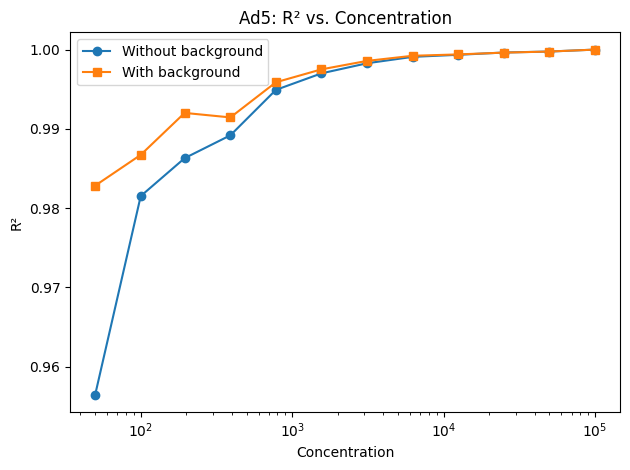

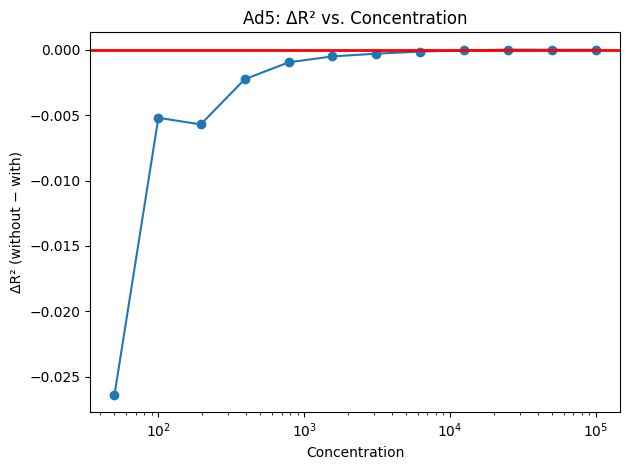

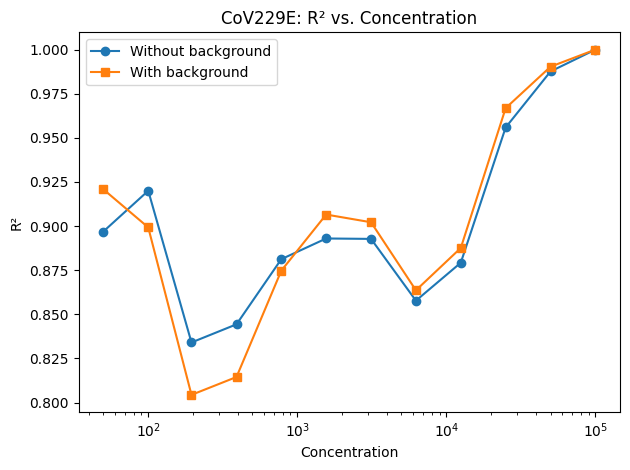

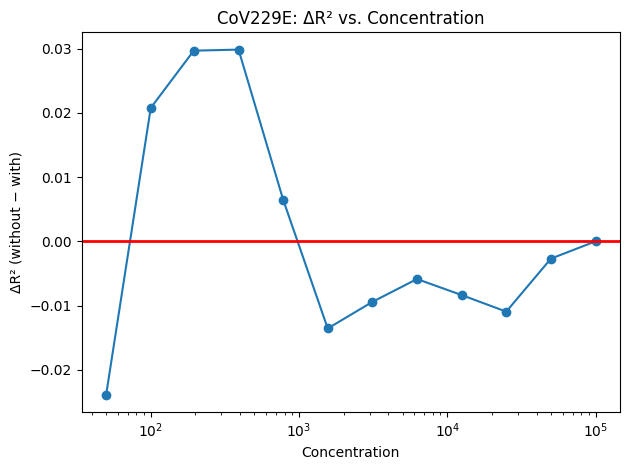

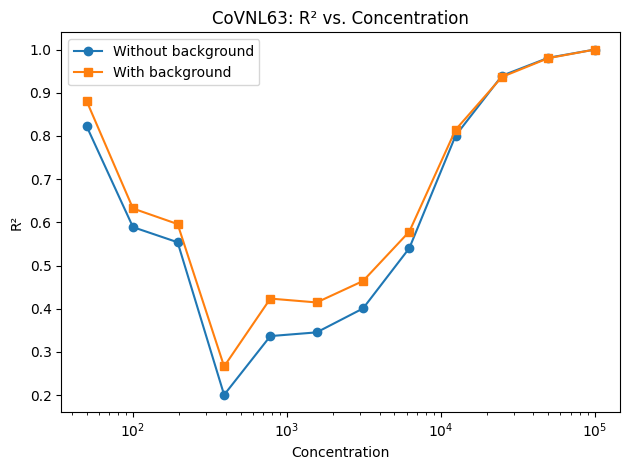

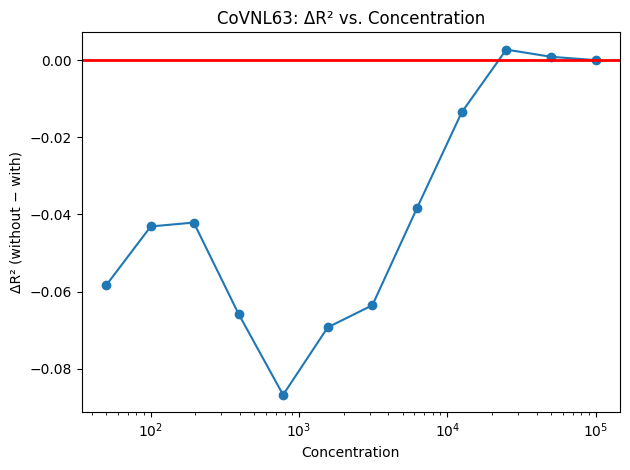

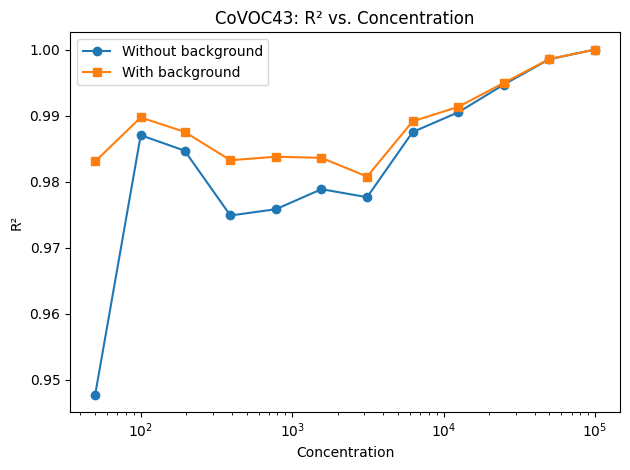

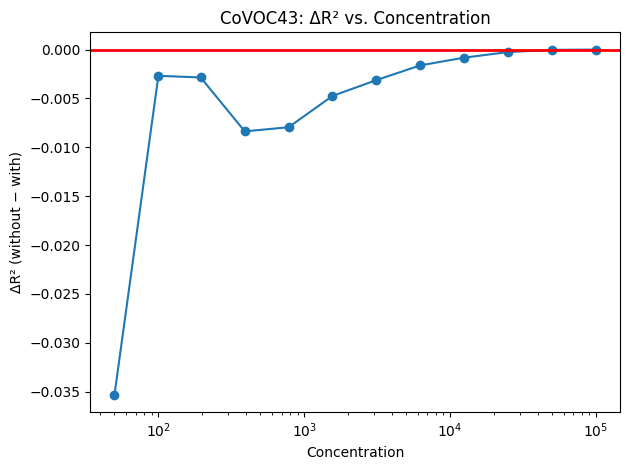

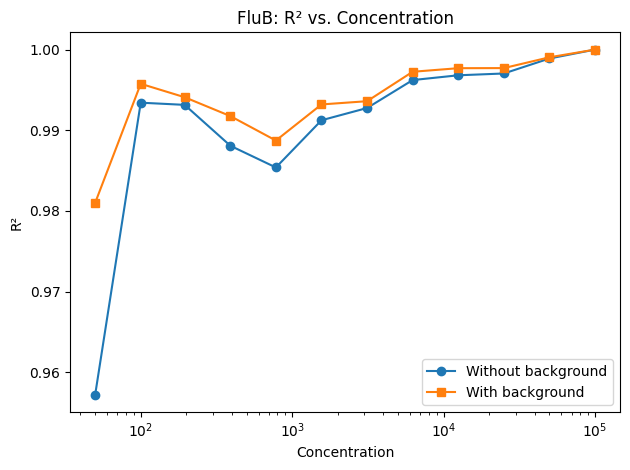

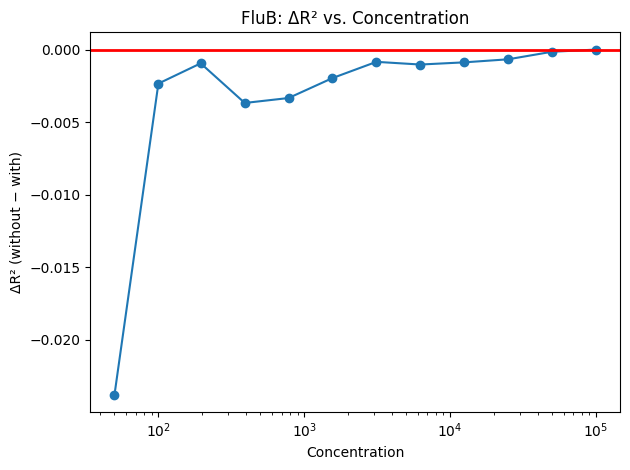

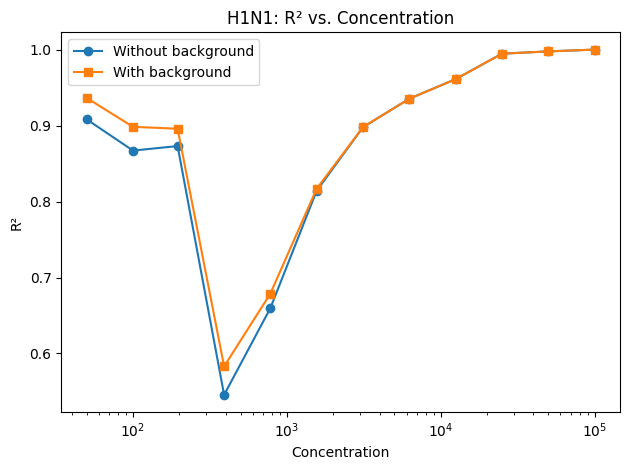

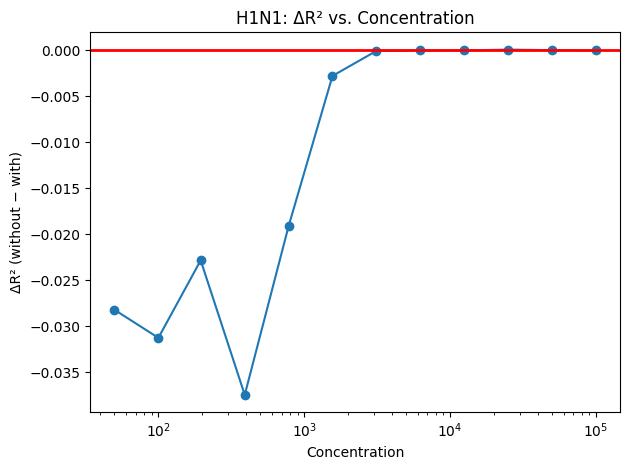

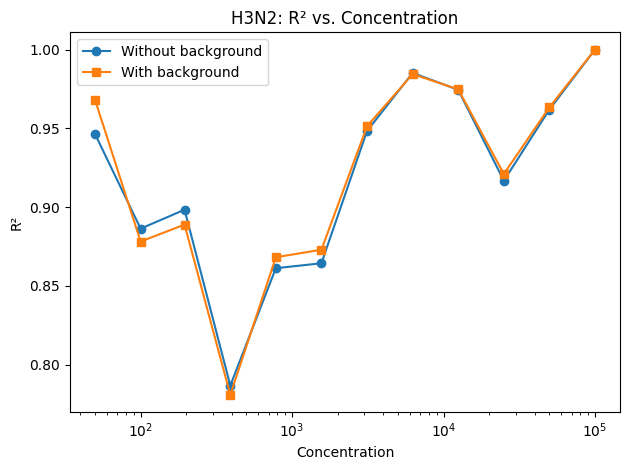

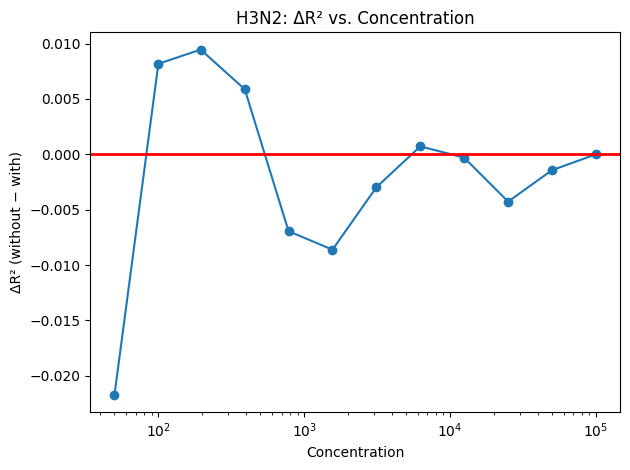

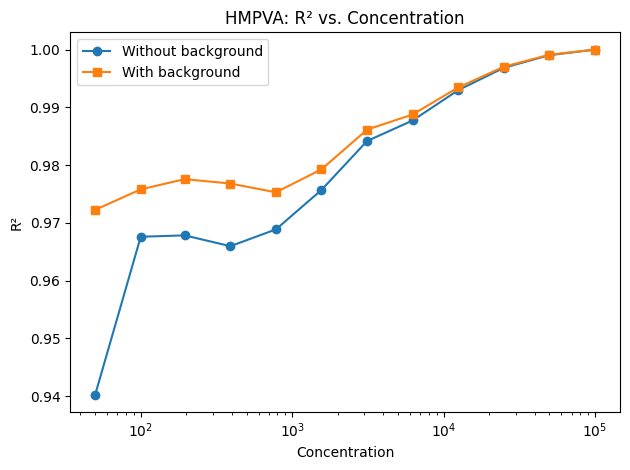

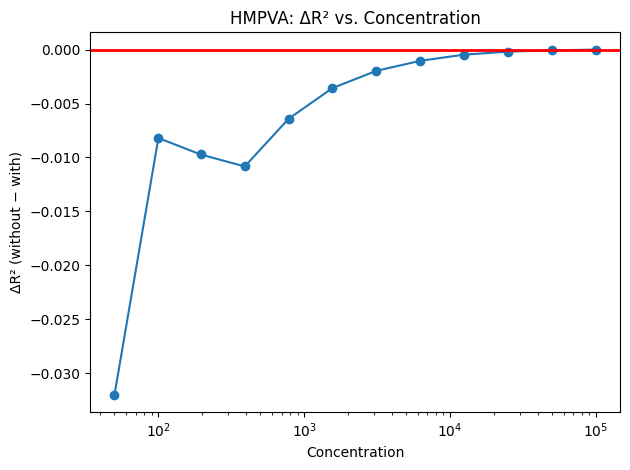

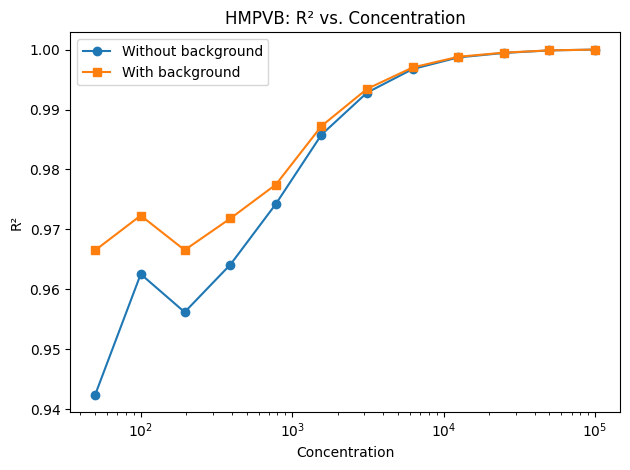

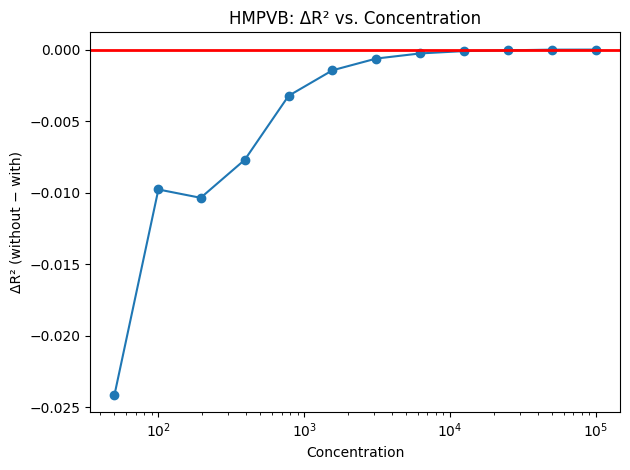

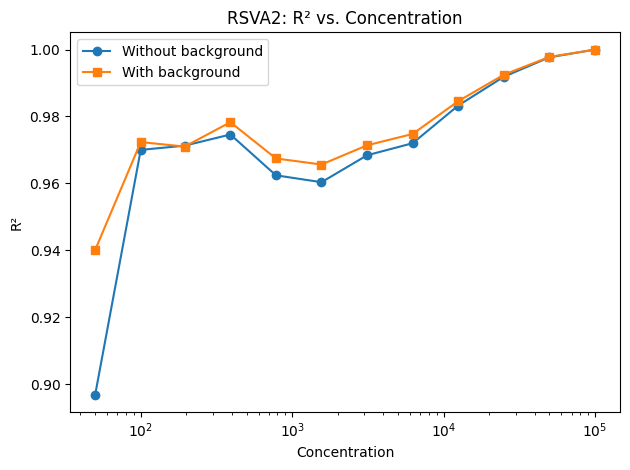

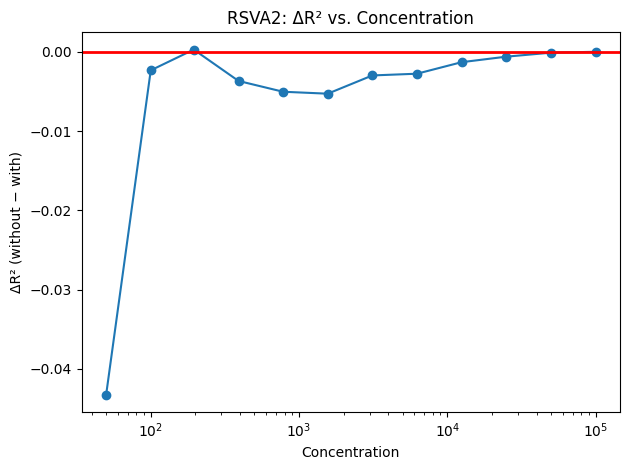

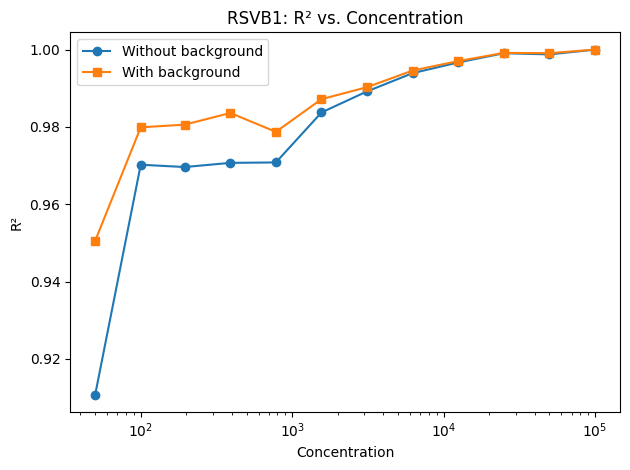

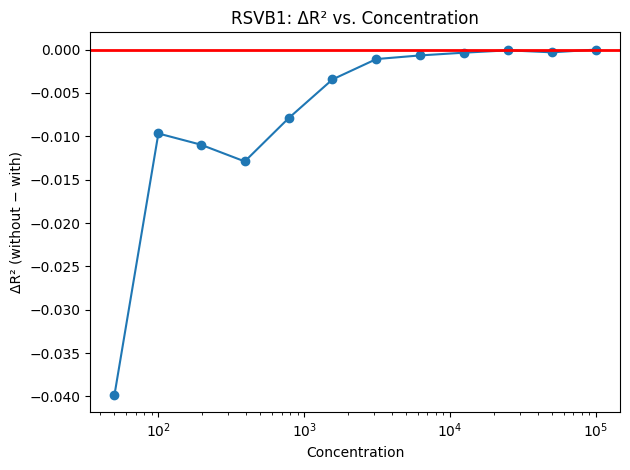

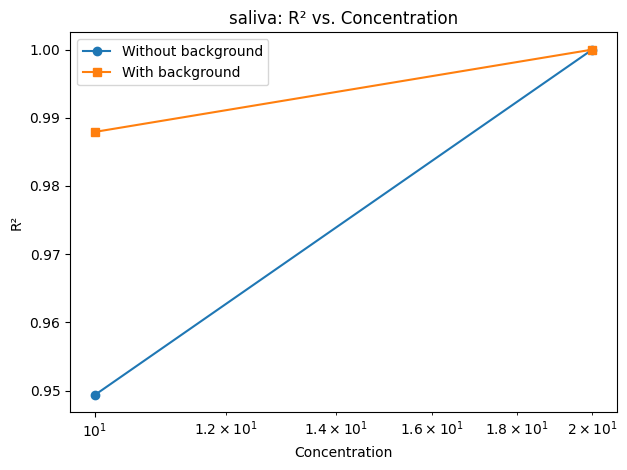

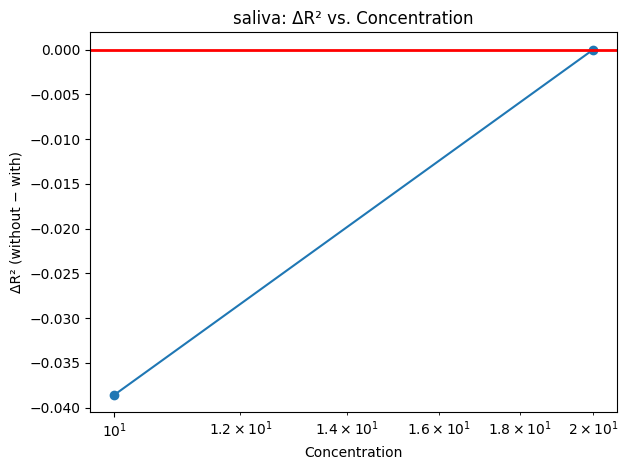

In [4]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# ——— 1. File paths ———
csv1 = "/home/zhao/Jiaheng Cui/Coefficient_fitting/04142025 - reconstructed vs real only using GLF (saliva)/04142025 - coefficients_(only_GLF)_constraint_1e-10 (saliva).csv"
csv2 = "/home/zhao/Jiaheng Cui/Coefficient_fitting/05062025 - reconstructed vs real only using GLF (saliva, with background)/05062025 - coefficients_(saliva, only_GLF, with background)_constraint_1e-10.csv"

# ——— 2. Load into DataFrames ———
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)

# ——— 3. Parse out virus name and integer concentration ———
def explode_label_conc(df):
    # convert "['Ad5']" → ['Ad5'], "[100.0]" → [100.0]
    df['label_list'] = df['Label'].apply(ast.literal_eval)
    df['virus']      = df['label_list'].str[0]
    df['conc_list'] = df['Conc'].apply(ast.literal_eval)
    df['conc']       = df['conc_list'].apply(lambda L: int(L[0]))
    return df

df1 = explode_label_conc(df1)
df2 = explode_label_conc(df2)

# ——— 4. Keep only the single-virus rows ———
df1_single = df1[df1['label_list'].str.len() == 1].copy()
df2_single = df2[df2['label_list'].str.len() == 1].copy()

# ——— 5. Get sorted list of viruses to plot ———
viruses = sorted(df1_single['virus'].unique())

# ——— 6. Loop and plot each virus ———
for virus in viruses:
    d1 = df1_single[df1_single['virus'] == virus].sort_values('conc')
    d2 = df2_single[df2_single['virus'] == virus].sort_values('conc')
    
    # ensure same conc. points
    common = d1['conc'].isin(d2['conc'])
    d1 = d1[common]
    d2 = d2[d2['conc'].isin(d1['conc'])]
    
    conc = d1['conc']
    r1   = d1['R2']
    r2   = d2['R2']
    
    # — Figure 1: R² vs. concentration (two curves) —
    plt.figure()
    plt.plot(conc, r1, marker='o', label='Without background')
    plt.plot(conc, r2, marker='s', label='With background')
    plt.xscale('log')                # if your concentrations span orders of magnitude
    plt.xlabel('Concentration')
    plt.ylabel('R²')
    plt.title(f'{virus}: R² vs. Concentration')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # — Figure 2: ΔR² vs. concentration —
    delta = r1.values - r2.values
    plt.figure()
    plt.plot(conc, delta, marker='o')
    plt.axhline(y=0, linewidth=2, color = 'r')
    plt.xscale('log')
    plt.xlabel('Concentration')
    plt.ylabel('ΔR² (without − with)')
    plt.title(f'{virus}: ΔR² vs. Concentration')
    plt.tight_layout()
    plt.show()


# Pred vs Real spectra

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import ast
import seaborn as sns

In [22]:
# Set up folders
DIFF_FOLDER = f"{WORKING_PATH}/{DATE} - difference_analysis (saliva, only_GLF, with background)"
R2_MAE_FOLDER = f"{WORKING_PATH}/{DATE} - r2_mae_analysis (saliva, only_GLF, with background)"

# Make sure folders exist
os.makedirs(DIFF_FOLDER, exist_ok=True)
os.makedirs(R2_MAE_FOLDER, exist_ok=True)

In [23]:
# 1. Basic font configuration
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# 2. Function to explicitly set font sizes and family on all text elements
def set_explicit_text_properties(fig, fontsize=None):
    """
    Sets font properties on all text elements in the figure.
    """
    for ax in fig.axes:
        # Set title font
        if ax.get_title():
            ax.set_title(ax.get_title(), fontname='Times New Roman', fontsize=28 if fontsize is None else fontsize)
        
        # Set axis label fonts
        ax.set_xlabel(ax.get_xlabel(), fontname='Times New Roman', fontsize=32 if fontsize is None else fontsize)
        ax.set_ylabel(ax.get_ylabel(), fontname='Times New Roman', fontsize=32 if fontsize is None else fontsize)
        
        # Set tick label fonts
        for tick in ax.get_xticklabels():
            tick.set_fontname('Times New Roman')
            tick.set_fontsize(28 if fontsize is None else fontsize)
        
        for tick in ax.get_yticklabels():
            tick.set_fontname('Times New Roman')
            tick.set_fontsize(28 if fontsize is None else fontsize)
        
        # Set legend font
        if ax.get_legend():
            for text in ax.get_legend().get_texts():
                text.set_fontname('Times New Roman')
                text.set_fontsize(20 if fontsize is None else fontsize)
    
    return fig

In [24]:
# Function to format concentration as integer if possible
def format_concentration(conc):
    try:
        # Check if it can be converted to an integer without loss
        if float(conc) == int(float(conc)):
            return str(int(float(conc)))
        return str(conc)
    except:
        return str(conc)

# Function to fix original data format for mixed viruses
def fix_original_data(original_df):
    """
    Fix mixed virus entries where part of the concentration is in the label
    """
    print("\nFixing the mixed virus format in the original data...")
    
    # Function to fix a mixed virus label and concentration
    def fix_mixed_virus_entry(label, conc):
        """
        Fix mixed virus entries where part of the concentration is in the label
        
        Args:
            label: The possibly corrupted label
            conc: The current concentration value
            
        Returns:
            tuple: (fixed_label, fixed_conc)
        """
        # Check if this is a corrupted mixed virus entry
        if isinstance(label, str) and '_[' in label:
            # Split at the '_[' which separates the virus names from the concentration
            parts = label.split('_[')
            if len(parts) >= 2:
                # First part is the fixed label
                fixed_label = parts[0]
                
                # Second part combined with conc is the fixed concentration
                fixed_conc = f"[{parts[1]}{conc}".rstrip("]") + "]"
                
                # If multiple '_[' sequences, handle more complex cases
                if len(parts) > 2:
                    # More complex parsing might be needed
                    pass
                    
                return fixed_label, fixed_conc
        
        # If not a corrupted entry or parsing fails, return original values
        return label, conc
    
    # Create a new dataframe with fixed labels and concentrations
    original_df_fixed = original_df.copy()
    
    # Apply the fix to each row
    fixed_rows = []
    for idx, row in original_df.iterrows():
        # Make a copy of the row
        new_row = row.copy()
        
        # Fix the label and concentration
        fixed_label, fixed_conc = fix_mixed_virus_entry(row['Label'], row['Conc'])
        
        # Update the row with fixed values
        new_row['Label'] = fixed_label
        new_row['Conc'] = fixed_conc
        
        # Add to the list of fixed rows
        fixed_rows.append(new_row)
    
    # Create a new dataframe from the fixed rows
    original_df_fixed = pd.DataFrame(fixed_rows)
    
    # Check that the fixing worked
    print("\nChecking fixed data:")
    mixed_virus_count = 0
    for idx, row in original_df_fixed.iterrows():
        label = row['Label']
        conc = row['Conc']
        
        if isinstance(label, str) and "'__'" in str(label) and '_[' not in str(label):
            mixed_virus_count += 1
            
            if mixed_virus_count <= 5:  # Show first 5 examples
                print(f"Fixed mixed virus: Label={label}, Conc={conc}")
    
    print(f"\nFound {mixed_virus_count} properly formatted mixed virus entries in the fixed data")
    
    return original_df_fixed

# Function to find matching concentration in another DataFrame
def find_matching_conc(label, conc_str, df):
    """
    Find a matching concentration for the given label in the DataFrame,
    using flexible matching to handle different string representations.
    """
    # Get all concentrations for this label in the DataFrame
    if not isinstance(df, pd.DataFrame) or df.empty:
        return None
        
    label_rows = df[df['Label'] == label]
    if label_rows.empty:
        return None
        
    # Try exact match
    if conc_str in label_rows['Conc'].values:
        return conc_str
        
    # Try comparing the actual values
    try:
        # Parse input concentration
        if isinstance(conc_str, str) and conc_str.startswith('[') and conc_str.endswith(']'):
            input_values = ast.literal_eval(conc_str)
            
            # Compare with each concentration in the DataFrame
            for df_conc in label_rows['Conc'].values:
                if isinstance(df_conc, str) and df_conc.startswith('[') and df_conc.endswith(']'):
                    try:
                        df_values = ast.literal_eval(df_conc)
                        # Check if values match, ignoring the string format
                        if input_values == df_values:
                            return df_conc
                    except:
                        continue
    except:
        pass
        
    # No match found
    return None

# Function to calculate wavelength regions with large differences
def find_difference_regions(real_spectrum, predicted_spectrum, wavenumbers, threshold_percentage=10):
    # Calculate absolute differences
    differences = np.abs(predicted_spectrum - real_spectrum)
    
    # Find the max difference value
    max_diff = np.max(differences)
    
    # Set a threshold as a percentage of the maximum difference
    threshold = max_diff * (threshold_percentage/100)
    
    # Find regions where difference exceeds threshold
    significant_regions = []
    in_region = False
    start_idx = None
    
    for i, diff in enumerate(differences):
        if diff > threshold and not in_region:
            in_region = True
            start_idx = i
        elif diff <= threshold and in_region:
            in_region = False
            significant_regions.append((wavenumbers[start_idx], wavenumbers[i-1]))
    
    # Handle case where the last region extends to the end
    if in_region:
        significant_regions.append((wavenumbers[start_idx], wavenumbers[-1]))
    
    return significant_regions, differences

# Create lookup dictionary for the real data for efficient matching
def create_lookup_dictionary(df):
    """
    Create a lookup dictionary for a DataFrame for efficient flexible matching.
    """
    lookup_dict = {}
    
    # For each label and concentration, store the actual data row index for fast lookup
    for idx, row in df.reset_index().iterrows():
        if 'Label' not in row or 'Conc' not in row:
            continue
            
        label = row['Label']
        conc = row['Conc']
        
        # Skip if label or conc is missing
        if pd.isna(label) or pd.isna(conc):
            continue
        
        # Store this row's index
        if label not in lookup_dict:
            lookup_dict[label] = {}
        
        # Store the original concentration
        lookup_dict[label][conc] = idx
        
        # Also store normalized versions of the concentration
        if isinstance(conc, str):
            # Store without brackets
            clean_conc = conc.strip('[]')
            lookup_dict[label][clean_conc] = idx
            
            # Store with double brackets (common parsing artifact)
            lookup_dict[label][f"[{conc}]"] = idx
            
            # For concentrations with underscores, store each possible format
            if '_' in conc:
                # Handle [100000.0_100000.0] format
                if conc.startswith('[') and conc.endswith(']'):
                    values = conc.strip('[]').split('_')
                    
                    # Store as list format
                    list_format = str(values)
                    lookup_dict[label][list_format] = idx
                    
                    # Store as tuple format
                    tuple_format = str(tuple(values))
                    lookup_dict[label][tuple_format] = idx
    
    return lookup_dict

# Fix and prepare data function - modified to handle MultiIndex consistently
def fix_and_prepare_data():
    """
    Fix any anomalies in the data and prepare lookup dictionaries for efficient matching.
    Ensures the returned DataFrame has the expected format for later use.
    """
    print("\nFixing data anomalies and preparing lookup dictionaries...")
    
    # First check if we need to fix the original data
    needs_fixing = False
    
    # Find all mixed virus entries in the original data
    mixed_virus_count = 0
    for idx, row in df.iterrows():
        if isinstance(row['Label'], str) and '_[' in row['Label']:
            mixed_virus_count += 1
            needs_fixing = True
            if mixed_virus_count <= 3:  # Show just a few examples
                print(f"Found corrupted mixed virus entry: {row['Label']}, {row['Conc']}")
    
    # If we found corrupted entries, fix the original data
    if needs_fixing:
        print(f"Found {mixed_virus_count} corrupted mixed virus entries, fixing...")
        fixed_original_df = fix_original_data(df)
        
        # Create new grouped data
        new_grouped_df = fixed_original_df.groupby(['Label', 'Conc']).mean()
        
        # Reset index to make Label and Conc columns for easier filtering
        new_grouped_df_reset = new_grouped_df.reset_index()
        
        # Create lookup dictionary from the original MultiIndex form
        real_lookup_dict = create_lookup_dictionary(new_grouped_df)
        
        return new_grouped_df_reset, real_lookup_dict
    else:
        print("No data anomalies found, using existing data.")
        
        # Check if grouped_df is a MultiIndex DataFrame
        if isinstance(grouped_df.index, pd.MultiIndex) and 'Label' in grouped_df.index.names:
            # Reset index to make Label and Conc columns for easier filtering
            grouped_df_reset = grouped_df.reset_index()
            real_lookup_dict = create_lookup_dictionary(grouped_df)
            return grouped_df_reset, real_lookup_dict
        else:
            # Already in the right format
            real_lookup_dict = create_lookup_dictionary(grouped_df)
            return grouped_df, real_lookup_dict

In [28]:
# Function to create standard comparison plots (real vs predicted)
def create_comparison_plot(label, conc, predicted_df, grouped_df_fixed, real_lookup_dict=None):
    """
    Create standard comparison plots showing real vs predicted spectra.
    """
    print(f"\nCreating comparison plot for {label} at {conc}")
    
    # Get predicted data
    pred_data = predicted_df[(predicted_df['Label'] == label) & (predicted_df['Conc'] == conc)]
    if pred_data.empty:
        print(f"  No predicted data found for {label} at {conc}")
        return
    
    # Get real data if available
    real_data = None
    comparison_possible = False
    
    if isinstance(grouped_df_fixed, pd.DataFrame):
        # First try direct match
        real_data = grouped_df_fixed[(grouped_df_fixed['Label'] == label) & (grouped_df_fixed['Conc'] == conc)]
        
        # If no direct match, try using the lookup dictionary
        if real_data.empty and real_lookup_dict is not None and label in real_lookup_dict:
            for alt_conc in real_lookup_dict.get(label, {}):
                idx = real_lookup_dict[label][alt_conc]
                real_data = grouped_df_fixed.iloc[[idx]]
                if not real_data.empty:
                    print(f"  Found real data using lookup dictionary with concentration: {alt_conc}")
                    break
        
        if not real_data.empty:
            comparison_possible = True
    
    # Extract wavenumbers
    wavenumbers = pred_data.columns[2:].astype(float)
    
    # Create figure for the plot
    fig = plt.figure(figsize=(8.7, 8))
    plt.xlabel('Wavenumbers')
    plt.ylabel('Intensity')
    
    # Plot real spectrum first (blue, solid)
    if comparison_possible and real_data is not None:
        real_spectrum = real_data.iloc[0, 2:].values
        plt.plot(wavenumbers, real_spectrum, color='blue', linewidth=2, linestyle='-', label='Real Spectrum')
    
    # Plot predicted spectrum (orange, dashed)
    predicted_spectrum = pred_data.iloc[0, 2:].values
    plt.plot(wavenumbers, predicted_spectrum, color='orange', linewidth=2, linestyle='--', label='Reconstructed Spectrum')
    
    # Calculate MAE if comparison is possible
    if comparison_possible and real_data is not None:
        mae = np.mean(np.abs(real_spectrum - predicted_spectrum))
        plt.title(f"MAE: {mae:.4f}")
        
        # Add to MAE records
        mae_records.append({
            'Label': label,
            'Concentration': conc,
            'MAE': mae
        })
    
    # Adjusting x-axis ticks
    tick_interval = 200.0
    plt.xticks(np.arange(start=450, stop=1701, step=tick_interval))
    
    # Add legend
    plt.legend(loc='best')
    set_explicit_text_properties(fig)
    plt.tight_layout()
    
    # Create a safe filename
    safe_label = str(label).replace('/', '_').replace('\\', '_').replace(':', '_')
    safe_conc = str(conc).replace('/', '_').replace('\\', '_').replace(':', '_')
    
    # Save the plot
    filename = f"{RESULT_FOLDER}/{DATE} - {safe_label}_Concentration_{safe_conc}.png"
    plt.savefig(filename, dpi=300)
    # plt.show()
    plt.close('all')
    plt.clf()
    plt.cla()
    
    # Create difference plot if comparison is possible
    if comparison_possible and real_data is not None:
        fig_diff = plt.figure(figsize=(8.7, 8))
        plt.xlabel('Wavenumbers')
        plt.ylabel('Intensity Difference')
        
        difference = predicted_spectrum - real_spectrum
        plt.plot(wavenumbers, difference, color='purple', linewidth=2, label='Reconstructed - Real')
        
        # Add a zero line for reference
        plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
        
        # Adjusting x-axis ticks
        plt.xticks(np.arange(start=450, stop=1701, step=tick_interval))
        plt.legend()
        set_explicit_text_properties(fig_diff)
        plt.tight_layout()
        
        # Filename for difference plot
        diff_filename = f"{RESULT_FOLDER}/{DATE} - {safe_label}_Concentration_{safe_conc}_difference.png"
        plt.savefig(diff_filename, dpi=300)
        # plt.show()
        plt.close('all')
        plt.clf()
        plt.cla()

# Function to create enhanced plots for all samples
def create_enhanced_plot(label, conc, predicted_df, grouped_df, highest_single_virus_conc_df, saliva_series, reference_series, real_lookup_dict=None):
    """
    Create enhanced plots for ALL samples (single and mixed virus) that include:
    1. Predicted spectrum (orange, dashed)
    2. Real spectrum (blue, solid) - if available
    3. All component spectra at their respective highest concentrations
    4. SiO2 reference component
    
    Args:
        label: Virus label (e.g., "['Ad5']" or "['CoVNL63', 'FluB']")
        conc: Concentration string or value
        predicted_df: DataFrame with predicted data
        grouped_df: DataFrame with real data
        highest_single_virus_conc_df: DataFrame with highest concentration single virus data
        reference_series: Series with SiO2 reference data
        real_lookup_dict: Dictionary for flexible matching of real data (optional)
    """
    import ast
    print(f"\nCreating enhanced plot for {label} at {conc}")
    
    # Get predicted data
    pred_data = predicted_df[(predicted_df['Label'] == label) & (predicted_df['Conc'] == conc)]
    if pred_data.empty:
        print(f"  No predicted data found for {label} at {conc}")
        return
    
    # Get real data if available
    real_data = None
    comparison_possible = False
    
    if isinstance(grouped_df, pd.DataFrame):
        # First try direct match
        real_data = grouped_df[(grouped_df['Label'] == label) & (grouped_df['Conc'] == conc)]
        
        # If no direct match, try using the lookup dictionary
        if real_data.empty and real_lookup_dict is not None and label in real_lookup_dict:
            for alt_conc in real_lookup_dict.get(label, {}):
                idx = real_lookup_dict[label][alt_conc]
                real_data = grouped_df.iloc[[idx]]
                if not real_data.empty:
                    print(f"  Found real data using lookup dictionary with concentration: {alt_conc}")
                    break
        
        if not real_data.empty:
            comparison_possible = True
    
    # Extract wavenumbers
    wavenumbers = pred_data.columns[2:].astype(float)
    
    # Parse component viruses from the label
    component_viruses = []
    
    try:
        # Try to use ast.literal_eval first to parse the label
        if isinstance(label, str) and label.startswith('[') and label.endswith(']'):
            try:
                parsed_label = ast.literal_eval(label)
                if isinstance(parsed_label, list):
                    component_viruses = parsed_label
                else:
                    component_viruses = [str(parsed_label)]
            except (SyntaxError, ValueError):
                # If that fails, use string splitting
                if "'__'" in label:
                    # Mixed virus case
                    clean_label = label.strip("[]' ")
                    parts = clean_label.split("'__'")
                    component_viruses = [part.strip("'") for part in parts]
                else:
                    # Single virus case
                    clean_label = label.strip("[]' ")
                    component_viruses = [clean_label]
        else:
            # Non-standard format, just use the label as is
            component_viruses = [label]
    except Exception as e:
        print(f"  Error parsing virus label: {e}")
        component_viruses = [str(label)]  # Fallback
    
    print(f"  Component viruses: {component_viruses}")
    
    # Create figure for the plot
    fig = plt.figure(figsize=(12, 10))  # Larger figure for more elements
    plt.xlabel('Wavenumbers')
    plt.ylabel('Intensity')
    
    # Plot component virus spectra
    component_spectra = []
    legend_labels = []
    
    # Add each virus component spectrum
    for i, virus in enumerate(component_viruses):
        # Format the virus label for lookup
        virus_label = f"['{virus}']"
        
        # Find the virus in the highest concentration data
        if virus_label in highest_single_virus_conc_df['Label'].values:
            # Get data for this virus
            virus_data = highest_single_virus_conc_df[highest_single_virus_conc_df['Label'] == virus_label]
            
            # Get the spectrum
            if not virus_data.empty:
                virus_spectrum = virus_data.iloc[0, 2:].values
                component_spectra.append(virus_spectrum)
                
                # Get the highest concentration for this virus
                virus_conc = virus_data.iloc[0]['Conc']
                
                # Plot with a distinctive color and line style
                colors = ['green', 'purple', 'red', 'brown', 'cyan']  # Colors for components
                line_style = '-.'  # Different line style for components
                color = colors[i % len(colors)]  # Cycle through colors
                
                plt.plot(wavenumbers, virus_spectrum, color=color, linestyle=line_style, 
                         linewidth=1.5, alpha=0.7)
                
                # Add to legend labels - include the actual highest concentration
                legend_label = f"{virus} Component (Highest conc: {virus_conc})"
                legend_labels.append(legend_label)
                print(f"  Added component: {legend_label}")
                
    # Add saliva component
    plt.plot(wavenumbers, saliva_series.values, color='coral', linestyle='-.', 
             linewidth=1.5, alpha=0.8)
    legend_labels.append("saliva")
    # print("  Added component: saliva")
    
    # Add SiO2 reference component
    plt.plot(wavenumbers, reference_series.values, color='dimgray', linestyle='-.', 
             linewidth=1.5, alpha=0.8)
    legend_labels.append("SiO2 Reference")
    # print("  Added component: SiO2 Reference")
    
    # Plot real spectrum first (blue, solid)
    if comparison_possible and real_data is not None:
        real_spectrum = real_data.iloc[0, 2:].values
        plt.plot(wavenumbers, real_spectrum, color='blue', linewidth=2, linestyle='-', label='Real Spectrum')
    
    # Plot predicted spectrum (orange, dashed)
    predicted_spectrum = pred_data.iloc[0, 2:].values
    plt.plot(wavenumbers, predicted_spectrum, color='orange', linewidth=2, linestyle='--', label='Reconstructed Spectrum')
    
    # Calculate MAE if comparison is possible
    if comparison_possible and real_data is not None:
        mae = np.mean(np.abs(real_spectrum - predicted_spectrum))
        # plt.title(f"MAE: {mae:.4f}")
        
        # Add to MAE records if not already added by the comparison plot
        mae_record_exists = False
        for record in mae_records:
            if record['Label'] == label and record['Concentration'] == conc:
                mae_record_exists = True
                break
                
        if not mae_record_exists:
            mae_records.append({
                'Label': label,
                'Concentration': conc,
                'MAE': mae
            })
    
    # Add component legend labels
    for i, label_text in enumerate(legend_labels):
        if "SiO2" in label_text:
            color = 'gray'
            line_style = ':'
        else:
            colors = ['green', 'purple', 'red', 'brown', 'cyan']
            color = colors[i % len(colors) if i < len(colors) else 0]
            line_style = '-.'
        plt.plot([], [], color=color, linestyle=line_style, linewidth=1.5, alpha=0.7, label=label_text)
    
    # Adjusting x-axis ticks
    tick_interval = 200.0
    plt.xticks(np.arange(start=450, stop=1701, step=tick_interval))
    
    # Add legend
    plt.legend(loc='best')
    set_explicit_text_properties(fig)
    plt.tight_layout()
    
    # Create a safe filename
    safe_label = str(label).replace('/', '_').replace('\\', '_').replace(':', '_')
    safe_conc = str(conc).replace('/', '_').replace('\\', '_').replace(':', '_')
    
    if "CoVNL63" not in safe_label:
        # Save the plot
        filename = f"{RESULT_FOLDER}/{DATE} - {safe_label}_Concentration_{safe_conc}_enhanced.png"
        plt.savefig(filename, dpi=300)
        # plt.show()
        plt.close('all')
        plt.clf()
        plt.cla()
    
    # # Create difference plot if comparison is possible
    # if comparison_possible and real_data is not None:
    #     fig_diff = plt.figure(figsize=(10, 8))
    #     plt.xlabel('Wavenumbers')
    #     plt.ylabel('Intensity Difference')
        
    #     difference = predicted_spectrum - real_spectrum
    #     plt.plot(wavenumbers, difference, color='purple', linewidth=2, label='Reconstructed - Real')
        
    #     # Add a zero line for reference
    #     plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
        
    #     # Adjusting x-axis ticks
    #     plt.xticks(np.arange(start=450, stop=1701, step=tick_interval))
    #     plt.legend()
    #     set_explicit_text_properties(fig_diff)
    #     plt.tight_layout()
        
    #     # Filename for difference plot
    #     diff_filename = f"{RESULT_FOLDER}/{DATE} - {safe_label}_Concentration_{safe_conc}_enhanced_difference.png"
    #     plt.savefig(diff_filename, dpi=300)
    #     # plt.show()
    #     plt.close('all')
    #     plt.clf()
    #     plt.cla()

# Main processing loop for all virus samples
def process_all_virus_samples(predicted_df, grouped_df_fixed, highest_single_virus_conc_df, saliva_series, reference_series, real_lookup_dict):
    """
    Process all virus samples, creating both standard comparison plots and enhanced plots.
    
    Returns:
        List of MAE records for each processed sample
    """
    global mae_records  # Using the global mae_records list
    mae_records = []
    
    print("\nProcessing all virus samples...")
    # Get all unique virus labels
    all_virus_labels = predicted_df['Label'].unique()
    
    # Categorize labels
    single_virus_labels = [label for label in all_virus_labels if isinstance(label, str) and not "'__'" in label]
    mixed_virus_labels = [label for label in all_virus_labels if isinstance(label, str) and "'__'" in label]
    
    print(f"Found {len(single_virus_labels)} single virus labels and {len(mixed_virus_labels)} mixed virus labels")
    
    # Process single virus samples first
    print("\nProcessing single virus samples...")
    for label in single_virus_labels:
        print(f"Working on {label}")
        # Get concentrations for this label
        conc_values = predicted_df[predicted_df['Label'] == label]['Conc'].unique()
        
        for conc in conc_values:
            conc_str = str(conc)
            print(f"Working on {label}, conc = {conc_str}")
            
            # # Create standard comparison plot
            # create_comparison_plot(label, conc, predicted_df, grouped_df_fixed, real_lookup_dict)
            
            # Create enhanced plot with components
            create_enhanced_plot(label, conc, predicted_df, grouped_df_fixed, 
                                highest_single_virus_conc_df, saliva_series, reference_series, real_lookup_dict)
    
    # Process mixed virus samples
    print("\nProcessing mixed virus samples...")
    for label in mixed_virus_labels:
        print(f"Working on {label}")
        # Get concentrations for this label
        conc_values = predicted_df[predicted_df['Label'] == label]['Conc'].unique()
        
        for conc in conc_values:
            conc_str = str(conc)
            print(f"Working on {label}, conc = {conc_str}")
            
            # Create standard comparison plot
            create_comparison_plot(label, conc, predicted_df, grouped_df_fixed, real_lookup_dict)
            
            # Create enhanced plot with components
            create_enhanced_plot(label, conc, predicted_df, grouped_df_fixed, 
                                highest_single_virus_conc_df, saliva_series, reference_series, real_lookup_dict)
    
    return mae_records

# Function to set explicit text properties for heatmaps
def set_explicit_text_properties_for_heatmap(fig):
    # Set font sizes for all text elements
    for ax in fig.axes:
        ax.title.set_fontsize(24)  # Title font size
        ax.xaxis.label.set_fontsize(22)  # X-axis label font size
        ax.yaxis.label.set_fontsize(22)  # Y-axis label font size
        ax.tick_params(axis='both', which='major', labelsize=20)  # Tick label font size
        
        # Set legend font size if legend exists
        if ax.get_legend() is not None:
            for text in ax.get_legend().get_texts():
                text.set_fontsize(20)

# Function to process difference regions and create analysis visualizations
def analyze_difference_regions(mae_records, predicted_df, grouped_df_fixed):
    """
    Analyze significant difference regions between real and predicted spectra.
    
    Returns:
        List of dictionaries with difference region information
    """
    difference_regions_data = []
    print("\nAnalyzing significant difference regions...")
    
    if not mae_records:
        print("No MAE records to analyze.")
        return difference_regions_data
    
    for record in mae_records:
        label = record['Label']
        conc = record['Concentration']
        
        # Get the data
        real_data = grouped_df_fixed[(grouped_df_fixed['Label'] == label) & (grouped_df_fixed['Conc'] == conc)]
        predicted_data = predicted_df[(predicted_df['Label'] == label) & (predicted_df['Conc'] == conc)]
        
        if real_data.empty or predicted_data.empty:
            continue
        
        # Get wavenumbers and spectra
        wavenumbers = real_data.columns[2:].astype(float)
        real_spectrum = real_data.iloc[0, 2:].values
        predicted_spectrum = predicted_data.iloc[0, 2:].values
        
        # Find regions with significant differences
        regions, differences = find_difference_regions(real_spectrum, predicted_spectrum, wavenumbers)
        
        # Parse virus names from label using ast.literal_eval for reliable parsing
        virus_names = []
        try:
            if isinstance(label, str) and label.startswith('[') and label.endswith(']'):
                try:
                    parsed_label = ast.literal_eval(label)
                    if isinstance(parsed_label, list):
                        virus_names = parsed_label
                    else:
                        virus_names = [str(parsed_label)]
                except (SyntaxError, ValueError):
                    # Fall back to string splitting
                    if "'__'" in label:
                        clean_label = label.strip("[]' ")
                        parts = clean_label.split("'__'")
                        virus_names = [part.strip("'") for part in parts]
                    else:
                        clean_label = label.strip("[]'")
                        virus_names = [clean_label]
            else:
                virus_names = [label]
        except:
            virus_names = [label]  # Default fallback
        
        # Store the difference regions for each virus name
        for virus_name in virus_names:
            for region_start, region_end in regions:
                difference_regions_data.append({
                    'Label': label,
                    'Focus_Virus': virus_name,
                    'Concentration': conc,
                    'Region_Start': region_start,
                    'Region_End': region_end,
                    'MAE_in_Region': np.mean(np.abs(predicted_spectrum[(wavenumbers >= region_start) & 
                                                                    (wavenumbers <= region_end)] - 
                                                real_spectrum[(wavenumbers >= region_start) & 
                                                            (wavenumbers <= region_end)]))
                })
    
    return difference_regions_data

# Function to create difference heatmaps
def create_difference_heatmaps(difference_regions_data, folder):
    """
    Create heatmaps visualizing the differences between real and predicted spectra.
    
    Args:
        difference_regions_data: List of dictionaries with difference region information
        folder: Folder to save the heatmaps
    """
    if not difference_regions_data:
        print("No difference regions data to visualize.")
        return
    
    print("\nCreating difference heatmaps...")
    
    # Group by virus
    virus_groups = {}
    for record in difference_regions_data:
        virus = record['Focus_Virus']
        if virus not in virus_groups:
            virus_groups[virus] = []
        virus_groups[virus].append(record)
    
    # Process each virus group
    for virus, records in virus_groups.items():
        print(f"Creating heatmap for {virus}...")
        
        # Group by label and concentration
        label_conc_groups = {}
        for record in records:
            key = (record['Label'], record['Concentration'])
            if key not in label_conc_groups:
                label_conc_groups[key] = []
            label_conc_groups[key].append(record)
        
        # Sort keys for consistent ordering
        sorted_keys = sorted(label_conc_groups.keys())
        
        # Create a matrix for the heatmap
        # Each row is a label+concentration, each column is a wavenumber
        wavenumbers = np.arange(450, 1701)
        heatmap_matrix = np.zeros((len(sorted_keys), len(wavenumbers)))
        
        # Fill the matrix with MAE values
        for i, key in enumerate(sorted_keys):
            for record in label_conc_groups[key]:
                start_idx = int(record['Region_Start'] - 450)
                end_idx = int(record['Region_End'] - 450)
                if start_idx < 0:
                    start_idx = 0
                if end_idx >= len(wavenumbers):
                    end_idx = len(wavenumbers) - 1
                
                # Set the MAE value for this region
                heatmap_matrix[i, start_idx:end_idx+1] = record['MAE_in_Region']
        
        # Create the heatmap
        fig, ax = plt.subplots(figsize=(12, 8))
        im = ax.imshow(heatmap_matrix, aspect='auto', cmap='viridis', interpolation='nearest')
        
        # Set axis labels
        ax.set_xlabel('Wavenumber')
        ax.set_ylabel('Sample')
        
        # Set y-tick labels
        ax.set_yticks(np.arange(len(sorted_keys)))
        # Create more descriptive y labels
        y_labels = []
        for key in sorted_keys:
            label, conc = key
            # Format label for display
            if isinstance(label, str) and "'__'" in label:
                # For mixed virus, show a simplified format
                clean_label = "Mixed"
            else:
                # For single virus, just show the virus name
                clean_label = "Single"
            y_labels.append(f"{clean_label} {conc}")
        ax.set_yticklabels(y_labels)
        
        # Create custom x-ticks for wavenumbers
        num_ticks = 7  # Number of ticks to show
        tick_indices = np.linspace(0, len(wavenumbers) - 1, num_ticks, dtype=int)
        ax.set_xticks(tick_indices)
        ax.set_xticklabels([str(wavenumbers[i]) for i in tick_indices])
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Mean Absolute Error')
        
        # Set title
        ax.set_title(f'Difference Analysis Heatmap for {virus}')
        
        # Apply text properties
        set_explicit_text_properties_for_heatmap(fig)
        
        # Save the figure
        plt.tight_layout()
        safe_virus = str(virus).replace('/', '_').replace('\\', '_').replace(':', '_')
        plt.savefig(os.path.join(folder, f"{safe_virus}_difference_heatmap.png"), dpi=300)
        plt.show()
        plt.close('all')
        plt.clf()
        plt.cla()

# Function to create MAE summary visualizations
def create_mae_summary_plots(mae_records, folder):
    """
    Create summary plots for MAE values.
    
    Args:
        mae_records: List of dictionaries with MAE information
        folder: Folder to save the plots
    """
    if not mae_records:
        print("No MAE records to visualize.")
        return
    
    print("\nCreating summary plots for MAE values...")
    
    # Convert to DataFrame
    mae_df = pd.DataFrame(mae_records)
    
    # Group by label
    label_groups = mae_df.groupby('Label')
    
    # Create a summary figure for single vs mixed virus MAE
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Categorize labels as single or mixed
    mae_df['Type'] = mae_df['Label'].apply(lambda x: 'Mixed' if "'__'" in str(x) else 'Single')
    
    # Calculate mean MAE for each type
    type_mae = mae_df.groupby('Type')['MAE'].mean()
    
    # Create bar chart
    type_mae.plot(kind='bar', ax=ax, color=['blue', 'orange'])
    ax.set_ylabel('Mean Absolute Error')
    ax.set_title('Average MAE by Virus Type')
    
    # Apply text properties
    set_explicit_text_properties(fig)
    
    # Save the figure
    plt.tight_layout()
    plt.savefig(os.path.join(folder, f"{DATE} - virus_type_mae_summary.png"), dpi=300)
    plt.show()
    plt.close('all')
    plt.clf()
    plt.cla()
    
    # Create individual plots for each virus
    for label, group in label_groups:
        if len(group) > 1:  # Only create plot if multiple concentrations
            print(f"Creating MAE summary plot for {label}...")
            
            # Sort by concentration if possible
            try:
                # Convert concentration to numeric if possible
                group = group.copy()
                group['NumericConc'] = group['Concentration'].apply(
                    lambda x: float(x.strip('[]')) if isinstance(x, str) else float(x))
                group = group.sort_values('NumericConc')
            except:
                # If conversion fails, keep original order
                pass
            
            # Create the plot
            fig, ax = plt.subplots(figsize=(10, 8))
            ax.plot(range(len(group)), group['MAE'], 'o-', linewidth=2, markersize=8)
            
            # Set tick labels
            ax.set_xticks(range(len(group)))
            ax.set_xticklabels(group['Concentration'], rotation=45)
            
            # Set labels and title
            ax.set_xlabel('Concentration')
            ax.set_ylabel('Mean Absolute Error')
            
            # Format label for title
            display_label = label
            if isinstance(label, str) and label.startswith('[') and label.endswith(']'):
                # Clean up the label for display
                if "'__'" in label:
                    # Mixed virus case, format with +
                    clean_label = label.strip("[]' ")
                    parts = clean_label.split("'__'")
                    display_label = " + ".join([part.strip("'") for part in parts])
                else:
                    # Single virus case
                    display_label = label.strip("[]'")
            
            ax.set_title(f'MAE vs. Concentration for {display_label}')
            
            # Apply text properties
            set_explicit_text_properties(fig)
            
            # Save the figure
            plt.tight_layout()
            safe_label = str(label).replace('/', '_').replace('\\', '_').replace(':', '_')
            plt.savefig(os.path.join(folder, f"{DATE} - {safe_label}_mae_summary.png"), dpi=300)
            plt.show()
            plt.close('all')
            plt.clf()
            plt.cla()


In [29]:
# Fix data anomalies and prepare lookup dictionaries
grouped_df_fixed, real_lookup_dict = fix_and_prepare_data()
print("Fixed DataFrame shape:", grouped_df_fixed.shape)
grouped_df_fixed



Fixing data anomalies and preparing lookup dictionaries...
No data anomalies found, using existing data.
Fixed DataFrame shape: (3478, 1253)


,Label,Conc,450,451,452,453,454,455,456,457,...,1691,1692,1693,1694,1695,1696,1697,1698,1699,1700
0,['Ad5'],[100.0],0.048205,0.034769,0.040359,0.054718,0.076333,0.101795,0.158513,0.144000,...,0.622128,0.531821,0.448128,0.365333,0.295692,0.205795,0.101718,-0.034179,-0.150641,-0.252846
1,['Ad5'],[100000.0],-0.113179,-0.099769,-0.084282,-0.067487,-0.049667,-0.031231,-0.006641,0.004103,...,0.398205,0.359897,0.323205,0.286154,0.251179,0.211077,0.166103,0.116103,0.061410,0.001462
2,['Ad5'],[12500.0],-0.111897,-0.095821,-0.078692,-0.060641,-0.041949,-0.023641,-0.000128,0.009333,...,0.425744,0.386000,0.346846,0.306333,0.266897,0.221744,0.171513,0.115051,0.055769,-0.007077
3,['Ad5'],[1562.0],-0.075154,-0.072538,-0.062359,-0.048590,-0.031692,-0.012897,0.019026,0.022897,...,0.492051,0.437692,0.386436,0.335179,0.289128,0.234590,0.173308,0.100718,0.029308,-0.042487
4,['Ad5'],[195.0],0.060897,0.054385,0.063615,0.079667,0.100846,0.123615,0.174282,0.155282,...,0.633821,0.532692,0.441179,0.351974,0.278513,0.189205,0.089846,-0.033821,-0.142513,-0.240564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3473,['RSVB1'],[50000.0],0.133487,0.146205,0.158179,0.170077,0.180923,0.189744,0.202256,0.198692,...,0.051821,0.036282,0.011846,-0.017769,-0.059410,-0.095538,-0.128949,-0.154462,-0.185410,-0.221282
3474,['RSVB1'],[6250.0],0.041974,0.060590,0.077846,0.095462,0.111744,0.124846,0.143179,0.135282,...,0.159385,0.112436,0.067333,0.023077,-0.016410,-0.061205,-0.109872,-0.169026,-0.222282,-0.272231
3475,['RSVB1'],[781.0],0.087026,0.075462,0.076846,0.083538,0.094513,0.107410,0.143000,0.125179,...,0.454487,0.367128,0.285000,0.204641,0.135846,0.054333,-0.035615,-0.146974,-0.243795,-0.330359
3476,['saliva'],[10.0],0.163114,0.143486,0.139286,0.141629,0.148714,0.157886,0.194343,0.164457,...,0.593543,0.485571,0.381714,0.278286,0.183143,0.079657,-0.028743,-0.150286,-0.265000,-0.376486



Processing all virus samples...
Found 25 single virus labels and 0 mixed virus labels

Processing single virus samples...
Working on ['Ad5']
Working on ['Ad5'], conc = [100.0]

Creating enhanced plot for ['Ad5'] at [100.0]
  Component viruses: ['Ad5']
  Added component: Ad5 Component (Highest conc: [100000.0])
Working on ['Ad5'], conc = [100000.0]

Creating enhanced plot for ['Ad5'] at [100000.0]
  Component viruses: ['Ad5']
  Added component: Ad5 Component (Highest conc: [100000.0])
Working on ['Ad5'], conc = [12500.0]

Creating enhanced plot for ['Ad5'] at [12500.0]
  Component viruses: ['Ad5']
  Added component: Ad5 Component (Highest conc: [100000.0])
Working on ['Ad5'], conc = [1562.0]

Creating enhanced plot for ['Ad5'] at [1562.0]
  Component viruses: ['Ad5']
  Added component: Ad5 Component (Highest conc: [100000.0])
Working on ['Ad5'], conc = [195.0]

Creating enhanced plot for ['Ad5'] at [195.0]
  Component viruses: ['Ad5']
  Added component: Ad5 Component (Highest conc: [10

/tmp/ipykernel_238993/675380870.py:193: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12, 10))  # Larger figure for more elements


  Added component: FluB Component (Highest conc: [100000.0])
Working on ['CoVNL63', 'FluB'], conc = [100000.0, 6250.0]

Creating enhanced plot for ['CoVNL63', 'FluB'] at [100000.0, 6250.0]
  Component viruses: ['CoVNL63', 'FluB']
  Added component: CoVNL63 Component (Highest conc: [100000.0])
  Added component: FluB Component (Highest conc: [100000.0])
Working on ['CoVNL63', 'FluB'], conc = [100000.0, 781.0]

Creating enhanced plot for ['CoVNL63', 'FluB'] at [100000.0, 781.0]
  Component viruses: ['CoVNL63', 'FluB']
  Added component: CoVNL63 Component (Highest conc: [100000.0])
  Added component: FluB Component (Highest conc: [100000.0])
Working on ['CoVNL63', 'FluB'], conc = [12500.0, 100.0]

Creating enhanced plot for ['CoVNL63', 'FluB'] at [12500.0, 100.0]
  Component viruses: ['CoVNL63', 'FluB']
  Added component: CoVNL63 Component (Highest conc: [100000.0])
  Added component: FluB Component (Highest conc: [100000.0])
Working on ['CoVNL63', 'FluB'], conc = [12500.0, 100000.0]

Cre

[{'Label': "['Ad5']", 'Concentration': '[100.0]', 'MAE': 0.06296089983056488},
 {'Label': "['Ad5']",
  'Concentration': '[100000.0]',
  'MAE': 1.0612963554546957e-08},
 {'Label': "['Ad5']",
  'Concentration': '[12500.0]',
  'MAE': 0.01780751361876406},
 {'Label': "['Ad5']", 'Concentration': '[1562.0]', 'MAE': 0.03595947405249866},
 {'Label': "['Ad5']", 'Concentration': '[195.0]', 'MAE': 0.04803333399030068},
 {'Label': "['Ad5']",
  'Concentration': '[25000.0]',
  'MAE': 0.014140175276638236},
 {'Label': "['Ad5']", 'Concentration': '[3125.0]', 'MAE': 0.02772749637387643},
 {'Label': "['Ad5']", 'Concentration': '[391.0]', 'MAE': 0.05513193444145929},
 {'Label': "['Ad5']", 'Concentration': '[50.0]', 'MAE': 0.07478162453665024},
 {'Label': "['Ad5']",
  'Concentration': '[50000.0]',
  'MAE': 0.011713731009817726},
 {'Label': "['Ad5']", 'Concentration': '[6250.0]', 'MAE': 0.0203726059791901},
 {'Label': "['Ad5']", 'Concentration': '[781.0]', 'MAE': 0.04255265918785333},
 {'Label': "['CoV229E

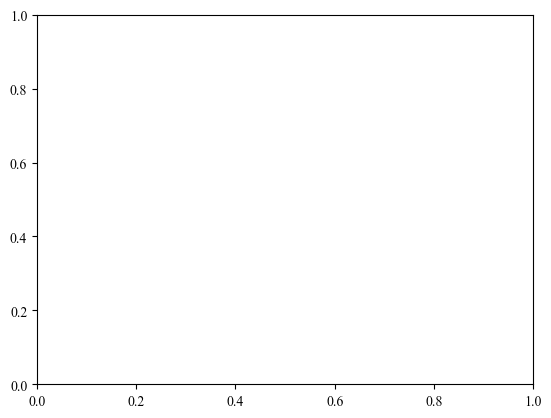

In [30]:
# Process all virus samples (creates both standard comparison and enhanced plots)
mae_records = process_all_virus_samples(predicted_df, grouped_df_fixed, highest_single_virus_conc_df, saliva_series, 
                                      reference_series, real_lookup_dict)
mae_records

In [ ]:
# Save MAE records to CSV
if mae_records:
    mae_df = pd.DataFrame(mae_records)
    mae_csv_path = os.path.join(R2_MAE_FOLDER, f"{DATE} - reconstruction_mae_summary.csv")
    mae_df.to_csv(mae_csv_path, index=False)
    print(f"MAE summary saved to {mae_csv_path}")
else:
    print("No MAE records collected, skipping MAE summary CSV.")

In [ ]:
# Analyze difference regions
difference_regions_data = analyze_difference_regions(mae_records, predicted_df, grouped_df_fixed)
difference_regions_data
# Save difference regions data
if difference_regions_data:
    difference_regions_df = pd.DataFrame(difference_regions_data)
    difference_regions_df.to_csv(os.path.join(DIFF_FOLDER, f"{DATE} - significant_difference_regions.csv"), index=False)
    print(f"Difference analysis saved to {DIFF_FOLDER}")
else:
    print("No difference regions data collected.")

In [ ]:
# Create visualizations for difference analysis
create_difference_heatmaps(difference_regions_data, DIFF_FOLDER)

# Create MAE summary visualizations
create_mae_summary_plots(mae_records, R2_MAE_FOLDER)

print("Analysis complete!")